# 19. Ethics, fairness, privacy and responsible machine learning

Every model in this course so far was judged by a number: accuracy, RMSE, AUC, expected
profit. This notebook is about everything that number leaves out. A model that predicts
loan repayment with 85 % accuracy can still deny credit to qualified applicants of one
group three times as often as to those of another; a model that never sees a protected
attribute can reconstruct it from a postcode; a model that generalises well can still
leak whether *you* were in its training set; and a classifier that is 97 % accurate on
clean data can be driven to 0 % by perturbations no human would notice. None of these
failures shows up in a cross-validation score, and all of them have happened in deployed
systems.

The good news is that most of these problems can be **measured**, and many can be
**mitigated**, with the tools you already have. This notebook builds those measurements
from scratch — group fairness metrics, calibration by group, the Laplace mechanism of
differential privacy, a membership-inference attack, an adversarial example — on the loan
data bundled with the course, whose bias mechanism is documented so that we can check our
diagnostics against the truth. Around the code sits the material that code cannot
replace: where bias enters a pipeline, why the popular fairness definitions cannot all
hold at once, what the law requires, and how to organise a project so that these
questions are asked *before* deployment rather than after the newspaper article.

**Prerequisites:** notebook 7 (classification metrics, thresholds and calibration) is
essential; notebook 17 (interpretability) and notebook 18 (model cards, monitoring) are
helpful. The capstone (notebook 20) applies the fairness check developed here to the churn
model.

## Learning objectives

After working through this notebook you will be able to

- name the main categories of harm that ML systems cause and locate, for a given pipeline, the stages at which bias enters (historical, representation, measurement, aggregation, evaluation, deployment);
- distinguish a *biased label* from the *outcome* it is supposed to measure, and recognise proxy variables;
- implement and interpret demographic parity, disparate impact (and the four-fifths rule), equal opportunity, equalised odds, predictive parity and calibration by group — from confusion matrices, without a library;
- explain why calibration by group and equalised odds cannot hold simultaneously when base rates differ (Chouldechova, 2017; Kleinberg et al., 2017), and verify it numerically;
- apply pre-processing (reweighing), in-processing (constraints) and post-processing (group-specific thresholds) interventions, and plot the accuracy–fairness trade-off they imply;
- explain the definition of $\varepsilon$-differential privacy, implement the Laplace mechanism for a mean query and reason about the privacy budget;
- demonstrate a membership-inference attack and an FGSM adversarial example, and explain what regularisation, abstention and monitoring do about them;
- run a responsible-ML checklist over a project and write a recommendation that a non-technical decision maker can act on.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from course_utils import set_style, PALETTE, load_loans

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
set_style()

## 1. Why this matters: harms, case studies and the sociotechnical frame

### 1.1 Four cases

**Recidivism risk scores (COMPAS).** In 2016 ProPublica analysed a commercial tool used
by US courts to estimate the risk that a defendant re-offends (Angwin et al., 2016).
Among defendants who did *not* re-offend, Black defendants had been labelled "high risk"
roughly twice as often as white defendants. The vendor replied that the tool was
*calibrated*: a given score meant the same re-offence rate for both groups. Both
statements were true. Chouldechova (2017) and Kleinberg, Mullainathan & Raghavan (2017)
then proved that they *must* conflict whenever the two groups have different base rates
— the result we reproduce numerically in section 3.4.

**Gender Shades.** Buolamwini & Gebru (2018) evaluated three commercial face-analysis
systems on a benchmark balanced by gender and skin type. Error rates for gender
classification were below 1 % for lighter-skinned men and up to 35 % for darker-skinned
women — a *representation* problem (training and benchmark sets dominated by lighter male
faces) that the vendors' own aggregate accuracy figures had hidden.

**A healthcare allocation algorithm.** Obermeyer et al. (2019) audited an algorithm used
for millions of US patients to identify who should receive extra care. Its target was
*healthcare cost*, a proxy for *need*. Because less money is spent on Black patients with
the same level of illness, Black patients had to be considerably sicker than white
patients to receive the same score; re-labelling the target to a direct measure of health
would have raised the share of Black patients flagged for extra help from about 18 % to
about 47 %. Nothing in the model was wrong — the *label* was.

**Hiring tools.** Systems that rank CVs learn from past hiring decisions; where those
decisions favoured one group, the model reproduces the preference and finds proxies for
it (a widely reported example is an experimental résumé screener, abandoned in 2018,
that had learned to penalise the word "women's"). The same mechanism — *learning the
historical decision instead of the outcome* — is at the heart of the loan example below.
O'Neil (2016) collects many more such cases; Mehrabi et al. (2021) survey the research
they triggered.

### 1.2 A taxonomy of harms

It helps to be specific about *what kind* of harm a system causes (Barocas, Hardt &
Narayanan, 2023):

| Harm | What happens | Example |
|---|---|---|
| **Allocation** | a resource or opportunity is withheld from a group | loans, jobs, bail, medical care |
| **Quality of service** | the system works worse for some people | speech or face recognition, translation, medical devices |
| **Representation** | people are stereotyped, demeaned or erased | image search results, word embeddings (notebook 15), generated text |
| **Privacy** | information about individuals is exposed or inferred | re-identification, membership inference (section 5) |
| **Safety** | the system fails under manipulation or shift | adversarial inputs, distribution shift (section 6) |

The first three are the classic "fairness" harms; the last two are usually filed under
"security" and "robustness" but belong to the same conversation, because the affected
people are the same and the remedies interact.

### 1.3 Fairness is a property of the system, not of the model

Selbst et al. (2019) describe five *traps* that technical work on fairness falls into:
the **framing trap** (evaluating the model in isolation from the humans and institutions
around it), the **portability trap** (assuming a fair solution in one context transfers
to another), the **formalism trap** (believing a mathematical definition captures what
fairness means to the people affected), the **ripple-effect trap** (ignoring how a new
tool changes the behaviour of the people using it), and the **solutionism trap**
(assuming the answer is a better model rather than, sometimes, no model). Keep these in
mind as we compute numbers: the numbers are indispensable, and they are not the answer.

## 2. Where bias enters the pipeline

Suresh & Guttag (2021) give a useful map of *where* in the life cycle things go wrong:

| Source | Definition | Example |
|---|---|---|
| **Historical bias** | the world that generated the data was itself unjust; a perfectly measured dataset still reflects it | past loan officers penalised one group |
| **Representation bias** | the sample under-represents parts of the population | few darker-skinned faces in a face dataset |
| **Measurement bias** | the features or the label are imperfect proxies for the quantities of interest, and the proxy quality differs across groups | healthcare cost as a proxy for need; arrests as a proxy for crime |
| **Aggregation bias** | one model is fitted to groups that would need different models | a single diabetes threshold across ethnic groups |
| **Evaluation bias** | the benchmark does not represent the deployment population | testing face recognition on a lighter-skinned benchmark |
| **Deployment bias** | the system is used in a way its designers did not intend | a risk score meant to allocate support used to set sentences |

(Their framework also names *learning bias* — modelling choices such as compressing a
model that amplify performance differences.) It is worth having the map in front of you as
a picture: each arrow of the pipeline is an opportunity for a different kind of harm, and
the diagnostics in this notebook are attached to particular arrows.

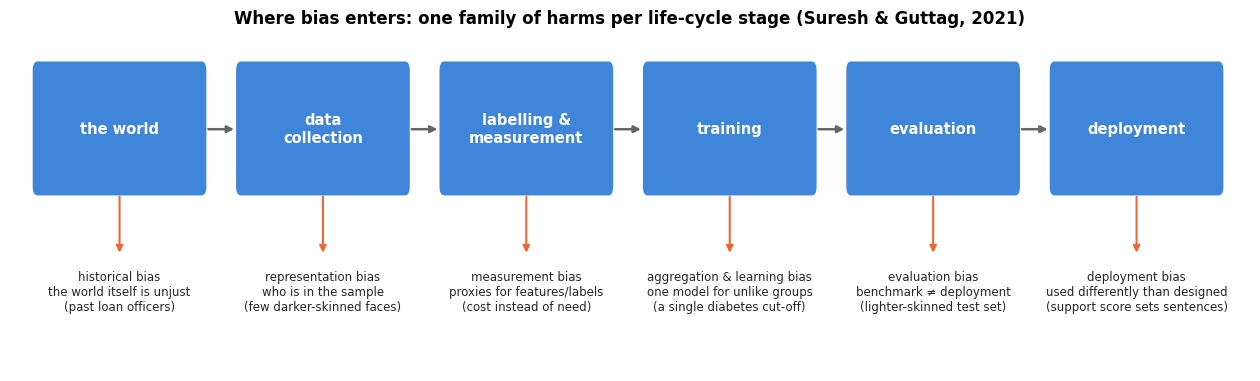

In [2]:
from matplotlib.patches import FancyBboxPatch

stages = ["the world", "data\ncollection", "labelling &\nmeasurement", "training", "evaluation", "deployment"]
sources = ["historical bias\nthe world itself is unjust\n(past loan officers)",
           "representation bias\nwho is in the sample\n(few darker-skinned faces)",
           "measurement bias\nproxies for features/labels\n(cost instead of need)",
           "aggregation & learning bias\none model for unlike groups\n(a single diabetes cut-off)",
           "evaluation bias\nbenchmark ≠ deployment\n(lighter-skinned test set)",
           "deployment bias\nused differently than designed\n(support score sets sentences)"]

fig, ax = plt.subplots(figsize=(16, 4.4))
for i, (stage, source) in enumerate(zip(stages, sources)):
    x = i * 2.6
    ax.add_patch(FancyBboxPatch((x, 1.7), 2.1, 0.75, boxstyle="round,pad=0.06",
                                facecolor=PALETTE[0], edgecolor="none", alpha=0.9))
    ax.text(x + 1.05, 2.07, stage, ha="center", va="center", color="white", fontsize=10.5, fontweight="semibold")
    if i < len(stages) - 1:
        ax.annotate("", xy=(x + 2.55, 2.07), xytext=(x + 2.15, 2.07),
                    arrowprops=dict(arrowstyle="-|>", color="0.4", lw=1.8))
    ax.annotate("", xy=(x + 1.05, 1.25), xytext=(x + 1.05, 1.65),
                arrowprops=dict(arrowstyle="-|>", color=PALETTE[1], lw=1.5))
    ax.text(x + 1.05, 1.15, source, ha="center", va="top", fontsize=8.5, color="0.15")
ax.set_xlim(-0.35, len(stages) * 2.6 - 0.1)
ax.set_ylim(0.5, 2.7)
ax.axis("off")
ax.set_title("Where bias enters: one family of harms per life-cycle stage (Suresh & Guttag, 2021)", fontsize=12)
plt.show()

Two of these sources are so common that we give them their own vocabulary.

**Label bias.** The target variable in a supervised dataset is often a *decision* made by
a human or a previous system (approved, hired, arrested, treated) rather than the
*outcome* we actually care about (repaid, performed well, committed a crime, needed
care). A model trained on the decision learns the decision — including whatever
prejudice went into it — and does so with excellent accuracy.

**Proxies.** Removing the protected attribute from the feature list does not remove the
information: postcode, name, school, browsing history, and many innocuous-looking
features are correlated with group membership, and a flexible model reconstructs the
attribute from them. Fairness "through unawareness" is not fairness (Dwork et al., 2012).

### 2.1 The loan data

The bundled loan data (`load_loans()`, 6 000 synthetic applications) were generated with
a *documented* bias mechanism (see `data/make_datasets.py`): an applicant's true ability
to repay depends only on legitimate financial factors, but the historical approval
decision applied an additional penalty to applicants of group B. Two target columns are
therefore available:

- `approved` — the **historical decision** (biased label);
- `repaid` — the **outcome** (whether the loan would be / was repaid), the label we
  actually want to predict.

Group B also has systematically lower incomes (a stand-in for historical inequality), and
the postcode prefix `zip_prefix` is a near-perfect proxy for the group. Let us look.

In [3]:
loans = load_loans()
print(loans.shape)
loans.head()

(6000, 13)


,applicant_id,age,group,education,income,employment_years,credit_history_years,existing_debt,loan_amount,purpose,zip_prefix,approved,repaid
0,1,40,B,bachelor,61500.0,5.1,11.5,6680.0,29000.0,car,101,1,1
1,2,45,A,master,73600.0,4.5,22.8,2780.0,17500.0,debt consolidation,204,1,1
2,3,57,A,master,46400.0,6.2,34.8,3370.0,11700.0,home improvement,202,1,1
3,4,37,B,bachelor,35600.0,6.8,7.3,3360.0,16500.0,home improvement,101,1,1
4,5,46,B,bachelor,40500.0,5.1,21.8,1450.0,12900.0,home improvement,102,1,1


In [4]:
by_group = loans.groupby("group").agg(n=("applicant_id", "size"),
                                      approval_rate=("approved", "mean"),
                                      repayment_rate=("repaid", "mean"),
                                      median_income=("income", "median"))
display(by_group.round(3))
print("postcode prefix by group:")
display(pd.crosstab(loans["group"], loans["zip_prefix"]))

,n,approval_rate,repayment_rate,median_income
group,,,,
A,3927,0.847,0.856,46300.0
B,2073,0.614,0.804,35600.0


postcode prefix by group:


zip_prefix,101,102,103,201,202,203,204
group,,,,,,,
A,0,0,0,953,985,991,998
B,724,726,623,0,0,0,0


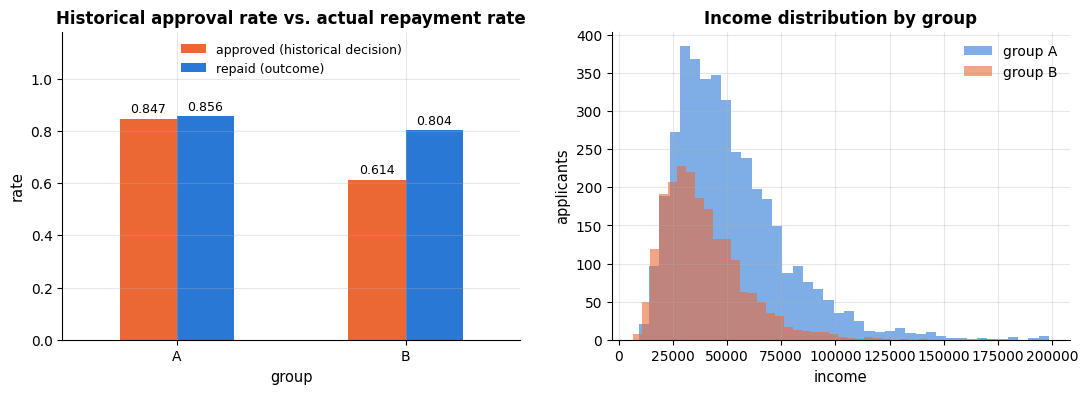

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
by_group[["approval_rate", "repayment_rate"]].plot.bar(ax=axes[0], color=[PALETTE[1], PALETTE[0]], rot=0)
axes[0].set_ylim(0, 1.18)
axes[0].set_ylabel("rate")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", fontsize=9, padding=2)
axes[0].set_title("Historical approval rate vs. actual repayment rate")
axes[0].legend(["approved (historical decision)", "repaid (outcome)"], loc="upper center", fontsize=9)
for g, color in zip(["A", "B"], [PALETTE[0], PALETTE[1]]):
    axes[1].hist(loans.loc[loans["group"] == g, "income"], bins=40, alpha=0.6, color=color, label=f"group {g}")
axes[1].set_xlabel("income")
axes[1].set_ylabel("applicants")
axes[1].set_title("Income distribution by group")
axes[1].legend()
plt.show()

The picture is the one from the case studies. Group B's *repayment* rate is a few points
lower than group A's (its members have lower incomes, which genuinely affects repayment),
but its historical *approval* rate is more than twenty points lower: the decisions were
far harsher on group B than the outcomes justify. And the postcode partitions the groups
exactly — any model that sees `zip_prefix` sees the group.

> **Key idea.** Before any modelling, ask two questions of the label: *is this the
> outcome I care about, or a past decision that stands in for it?* and *for which groups
> is the proxy worse?* No later intervention can fully repair a label that measures the
> wrong thing.

### 2.2 Two models: imitating the decision vs. predicting the outcome

We fit two logistic-regression pipelines (notebook 7). The **historical model** does what
a naive project would do: predict `approved` from every available column, including
`group` and `zip_prefix`. The **outcome model** predicts `repaid` from the financial
features only. Both are evaluated on the same held-out applicants, and — this is the
important choice — both are evaluated against the *outcome* `repaid`, because the
historical decision is not a valid ground truth.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

numeric = ["age", "income", "employment_years", "credit_history_years", "existing_debt", "loan_amount"]
categorical = ["education", "purpose"]

def make_model(num_cols, cat_cols):
    prep = ColumnTransformer([("num", StandardScaler(), num_cols),
                              ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])
    return Pipeline([("prep", prep), ("lr", LogisticRegression(max_iter=2000))])

# stratify on group x outcome so that both groups keep their base rates in the test set
strata = loans["group"] + loans["repaid"].astype(str)
train, test = train_test_split(loans, test_size=0.3, stratify=strata, random_state=RANDOM_STATE)
y_test = test["repaid"].to_numpy()          # the OUTCOME is the ground truth for evaluation
g_test = test["group"].to_numpy()

all_features = numeric + categorical + ["group", "zip_prefix"]
hist_model = make_model(numeric, categorical + ["group", "zip_prefix"]).fit(train[all_features], train["approved"])
outcome_model = make_model(numeric, categorical).fit(train[numeric + categorical], train["repaid"])

p_hist = hist_model.predict_proba(test[all_features])[:, 1]
p_out = outcome_model.predict_proba(test[numeric + categorical])[:, 1]
print(f"test set: {len(test)} applicants, group A {np.mean(g_test == 'A'):.1%}, group B {np.mean(g_test == 'B'):.1%}")
print(f"repayment base rate: A {y_test[g_test == 'A'].mean():.3f}   B {y_test[g_test == 'B'].mean():.3f}")

test set: 1800 applicants, group A 65.4%, group B 34.6%
repayment base rate: A 0.857   B 0.804


A score is not a decision. The bank earns interest on a repaid loan and loses (most of)
the principal on a default; we take a default to cost four times what a repaid loan
earns. With a calibrated probability $p$ of repayment, approving is profitable when
$p \cdot 1 > (1 - p) \cdot 4$, i.e. when $p > 0.8$ (the cost-sensitive threshold of
notebook 7). The same rule and the same profit function are used for every model below,
so that fairness and business value are always measured on the same footing.

In [7]:
GAIN, LOSS = 1.0, 4.0                      # profit units: +1 per repaid loan, -4 per default
TAU = LOSS / (GAIN + LOSS)                 # approve when P(repaid) >= 0.8

def mean_profit(y_true, y_pred):
    """Average profit per applicant of a set of approve/deny decisions."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    gains = GAIN * np.sum((y_pred == 1) & (y_true == 1))
    losses = LOSS * np.sum((y_pred == 1) & (y_true == 0))
    return (gains - losses) / len(y_true)

yhat_hist = (p_hist >= TAU).astype(int)
yhat_out = (p_out >= TAU).astype(int)
print(f"decision threshold tau = {TAU:.2f}")
print(f"profit per applicant — approve everyone: {mean_profit(y_test, np.ones_like(y_test)):.3f}")
print(f"profit per applicant — historical decisions (column 'approved'): {mean_profit(y_test, test['approved']):.3f}")
print(f"profit per applicant — historical model:  {mean_profit(y_test, yhat_hist):.3f}")
print(f"profit per applicant — outcome model:     {mean_profit(y_test, yhat_out):.3f}")

decision threshold tau = 0.80
profit per applicant — approve everyone: 0.192
profit per applicant — historical decisions (column 'approved'): 0.294
profit per applicant — historical model:  0.337
profit per applicant — outcome model:     0.409


The outcome model is the most profitable of the four policies — being unfair was not
even good business. Before quantifying *how* unfair each policy is, look at where the
decisions come from: one threshold applied to two score distributions.

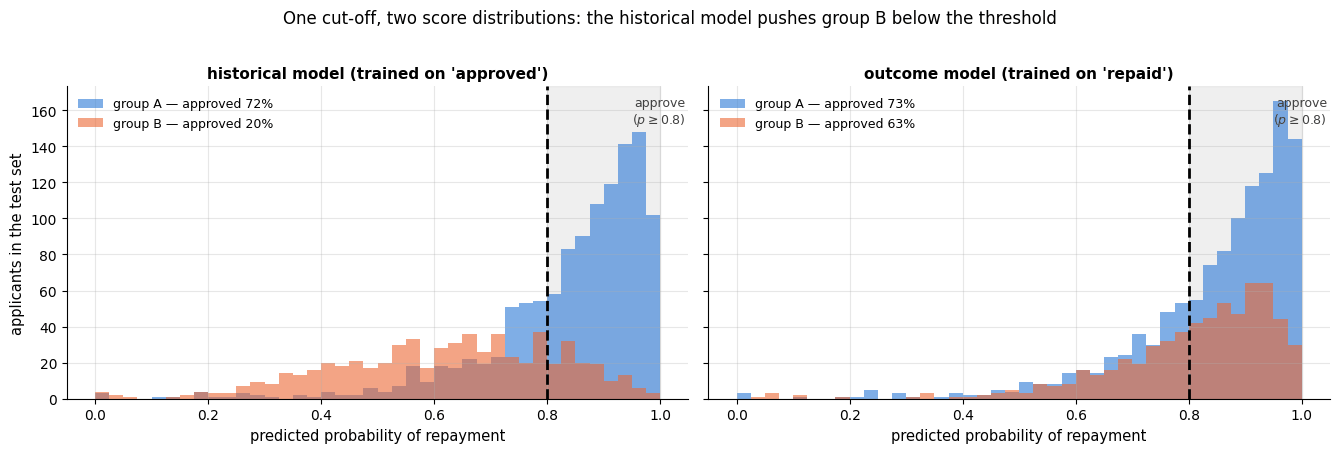

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4), sharey=True)
score_bins = np.linspace(0, 1, 41)
for ax, (name, p) in zip(axes, [("historical model (trained on 'approved')", p_hist),
                                ("outcome model (trained on 'repaid')", p_out)]):
    for g, color in zip(["A", "B"], [PALETTE[0], PALETTE[1]]):
        m = g_test == g
        ax.hist(p[m], bins=score_bins, alpha=0.6, color=color,
                label=f"group {g} — approved {np.mean(p[m] >= TAU):.0%}")
    ax.axvspan(TAU, 1.0, color="0.8", alpha=0.3, zorder=0)
    ax.axvline(TAU, color="black", lw=2, ls="--")
    ax.set_xlabel("predicted probability of repayment")
    ax.set_title(name, fontsize=11)
    ax.legend(loc="upper left", fontsize=9)
    ax.annotate(f"approve\n($p \\geq {TAU:.1f}$)", xy=(0.995, 0.97), xycoords="axes fraction",
                ha="right", va="top", fontsize=9, color="0.25")
axes[0].set_ylabel("applicants in the test set")
fig.suptitle("One cut-off, two score distributions: the historical model pushes group B below the threshold", y=1.02)
plt.tight_layout()
plt.show()

Both panels use the *same* rule ($p \ge 0.8$), but the historical model's scores for group
B sit almost entirely to the left of the cut-off, while the outcome model's two
distributions overlap. Everything in the next section is a way of putting a number on
that difference.

## 3. Measuring fairness

### 3.1 Three criteria

Let $A$ be the sensitive attribute (here the group), $Y \in \{0, 1\}$ the outcome, $R$
the model's score and $\hat{Y} = \mathbb{1}[R \ge \tau]$ the decision. Almost every
group-fairness definition in the literature is an instance of one of three conditional
independence statements (Barocas, Hardt & Narayanan, 2023, ch. 3):

| Criterion | Statement | Common names and metrics |
|---|---|---|
| **Independence** | $\hat{Y} \perp A$ | demographic (statistical) parity, disparate impact |
| **Separation** | $\hat{Y} \perp A \mid Y$ | equalised odds; equal opportunity (only $Y=1$) |
| **Sufficiency** | $Y \perp A \mid R$ | calibration by group; predictive parity (only $\hat{Y}=1$) |

Concretely, for two groups $a$ and $b$:

- **Demographic parity difference** $= P(\hat{Y}=1 \mid A=a) - P(\hat{Y}=1 \mid A=b)$: the
  gap in *selection rates*. The **disparate impact ratio** is the quotient
  $P(\hat{Y}=1 \mid A=b)\,/\,P(\hat{Y}=1 \mid A=a)$ of the disadvantaged to the
  advantaged group's selection rate; US employment guidelines (the *four-fifths rule*,
  EEOC, 1978) treat a ratio below $0.8$ as evidence of adverse impact (Feldman et al.,
  2015).
- **Equal opportunity difference** $= \mathrm{TPR}_a - \mathrm{TPR}_b$, where
  $\mathrm{TPR} = P(\hat{Y}=1 \mid Y=1)$: among people who *would* repay, are both groups
  approved equally often? (Hardt, Price & Srebro, 2016.)
- **Equalised odds difference** $= \max(|\mathrm{TPR}_a - \mathrm{TPR}_b|,\ |\mathrm{FPR}_a - \mathrm{FPR}_b|)$:
  additionally, among people who would default, are both groups (wrongly) approved
  equally often?
- **Predictive parity difference** $= \mathrm{PPV}_a - \mathrm{PPV}_b$, where
  $\mathrm{PPV} = P(Y=1 \mid \hat{Y}=1)$: among approved applicants, is the repayment
  rate the same? **Calibration by group** is the score-level version:
  $P(Y=1 \mid R=r, A=a) = r$ for every group and every score $r$.

Which of these is "fairness"? Independence says the *outcome of the decision* should not
depend on the group — appropriate when we distrust the labels or want to correct
historical imbalance. Separation says the *error rates* should not depend on the group —
appropriate when the label is trustworthy and errors are what harm people (a qualified
applicant denied). Sufficiency says the *score means the same thing* for everyone — what
a decision maker who uses the score needs. They are different values, section 3.4 shows
they are mathematically incompatible in general, and Corbett-Davies & Goel (2018) argue
that each of them can be satisfied by a policy that is plainly unfair. We will compute all
of them.

### 3.2 Everything from the per-group confusion matrix

All of these are functions of the per-group confusion matrix, so we compute that once.

In [9]:
def group_rates(y_true, y_pred, group):
    """Per-group confusion-matrix rates. Rows: groups; columns: n, base rate, selection rate, TPR, FPR, FNR, PPV, accuracy."""
    y_true, y_pred, group = (np.asarray(a) for a in (y_true, y_pred, group))
    rows = {}
    for g in np.unique(group):
        m = group == g
        yt, yp = y_true[m], y_pred[m]
        tp = np.sum((yt == 1) & (yp == 1)); fp = np.sum((yt == 0) & (yp == 1))
        fn = np.sum((yt == 1) & (yp == 0)); tn = np.sum((yt == 0) & (yp == 0))
        rows[g] = {"n": int(m.sum()), "base rate": yt.mean(), "selection rate": yp.mean(),
                   "TPR": tp / (tp + fn), "FPR": fp / (fp + tn), "FNR": fn / (tp + fn),
                   "PPV": tp / max(tp + fp, 1), "accuracy": (tp + tn) / m.sum()}
    return pd.DataFrame(rows).T.astype({"n": int})

def fairness_summary(rates):
    """Gap metrics between the group with the highest and the lowest value of each rate."""
    sel = rates["selection rate"]
    return pd.Series({
        "demographic parity difference": sel.max() - sel.min(),
        "disparate impact ratio": sel.min() / sel.max(),
        "equal opportunity difference": rates["TPR"].max() - rates["TPR"].min(),
        "equalised odds difference": max(rates["TPR"].max() - rates["TPR"].min(), rates["FPR"].max() - rates["FPR"].min()),
        "predictive parity difference": rates["PPV"].max() - rates["PPV"].min(),
    })

rates_hist = group_rates(y_test, yhat_hist, g_test)
rates_out = group_rates(y_test, yhat_out, g_test)
print("historical model (trained on 'approved', all features):")
display(rates_hist.round(3))
print("outcome model (trained on 'repaid', financial features only):")
display(rates_out.round(3))

historical model (trained on 'approved', all features):


,n,base rate,selection rate,TPR,FPR,FNR,PPV,accuracy
A,1178,0.857,0.721,0.777,0.385,0.223,0.923,0.754
B,622,0.804,0.196,0.228,0.066,0.772,0.934,0.367


outcome model (trained on 'repaid', financial features only):


,n,base rate,selection rate,TPR,FPR,FNR,PPV,accuracy
A,1178,0.857,0.733,0.789,0.396,0.211,0.922,0.762
B,622,0.804,0.625,0.706,0.295,0.294,0.907,0.706


In [10]:
summary = pd.DataFrame({"historical decisions": fairness_summary(group_rates(y_test, test["approved"], g_test)),
                        "historical model": fairness_summary(rates_hist),
                        "outcome model": fairness_summary(rates_out)})
summary.round(3)

,historical decisions,historical model,outcome model
demographic parity difference,0.261,0.525,0.107
disparate impact ratio,0.692,0.272,0.854
equal opportunity difference,0.226,0.549,0.083
equalised odds difference,0.367,0.549,0.101
predictive parity difference,0.003,0.011,0.015


Read the historical model's row for group B: its selection rate is a quarter of group
A's (disparate impact ratio far below 0.8), and — the number that matters most to the
people affected — its **true positive rate** is about 0.23 against 0.78 for group A. A
qualified applicant of group B is denied roughly three times as often as an equally
qualified applicant of group A. The outcome model removes most of this, but not all: a
selection-rate gap of about 0.11 and a TPR gap of about 0.08 remain, because group B's
lower incomes translate into genuinely lower predicted repayment probabilities. Whether
*that* residual gap is acceptable is a question about the world, not about the model —
we return to it in section 7.

Per-group confusion matrices make the same point visually; we normalise each row so the
cells read as rates (TPR, FNR in the "would repay" row; FPR, TNR in the "would default"
row).

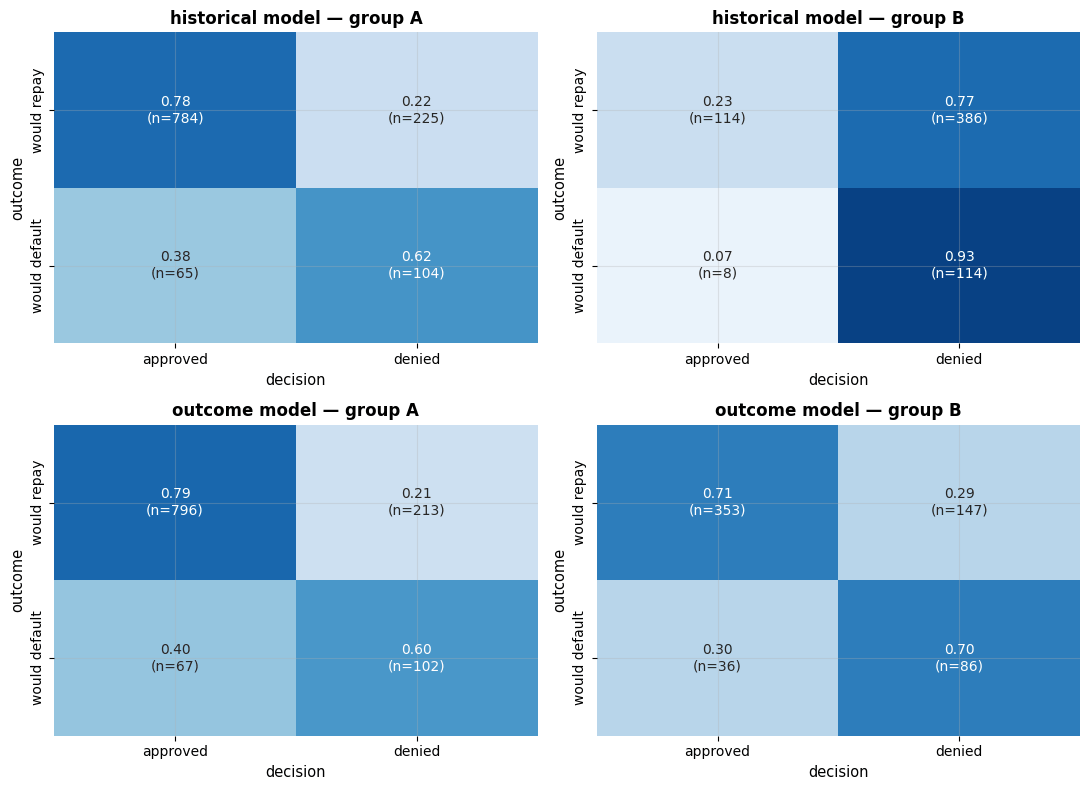

In [11]:
def plot_group_confusion(y_true, y_pred, group, ax_row, model_name):
    for ax, g in zip(ax_row, np.unique(group)):
        m = np.asarray(group) == g
        yt, yp = np.asarray(y_true)[m], np.asarray(y_pred)[m]
        cm = np.array([[np.sum((yt == r) & (yp == c)) for c in (1, 0)] for r in (1, 0)])   # rows: repaid, default
        cm_norm = cm / cm.sum(axis=1, keepdims=True)
        sns.heatmap(cm_norm, annot=[[f"{v:.2f}\n(n={c})" for v, c in zip(rv, rc)] for rv, rc in zip(cm_norm, cm)],
                    fmt="", cmap="Blues", vmin=0, vmax=1, cbar=False, ax=ax,
                    xticklabels=["approved", "denied"], yticklabels=["would repay", "would default"])
        ax.set_title(f"{model_name} — group {g}")
        ax.set_xlabel("decision")
        ax.set_ylabel("outcome")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plot_group_confusion(y_test, yhat_hist, g_test, axes[0], "historical model")
plot_group_confusion(y_test, yhat_out, g_test, axes[1], "outcome model")
plt.tight_layout()
plt.show()

Every metric of section 3.1 is a *gap between two bars* of the same colour pair. Drawing
all of them side by side for the three policies makes the comparison immediate — and shows
that the policies disagree on some criteria while agreeing on others.

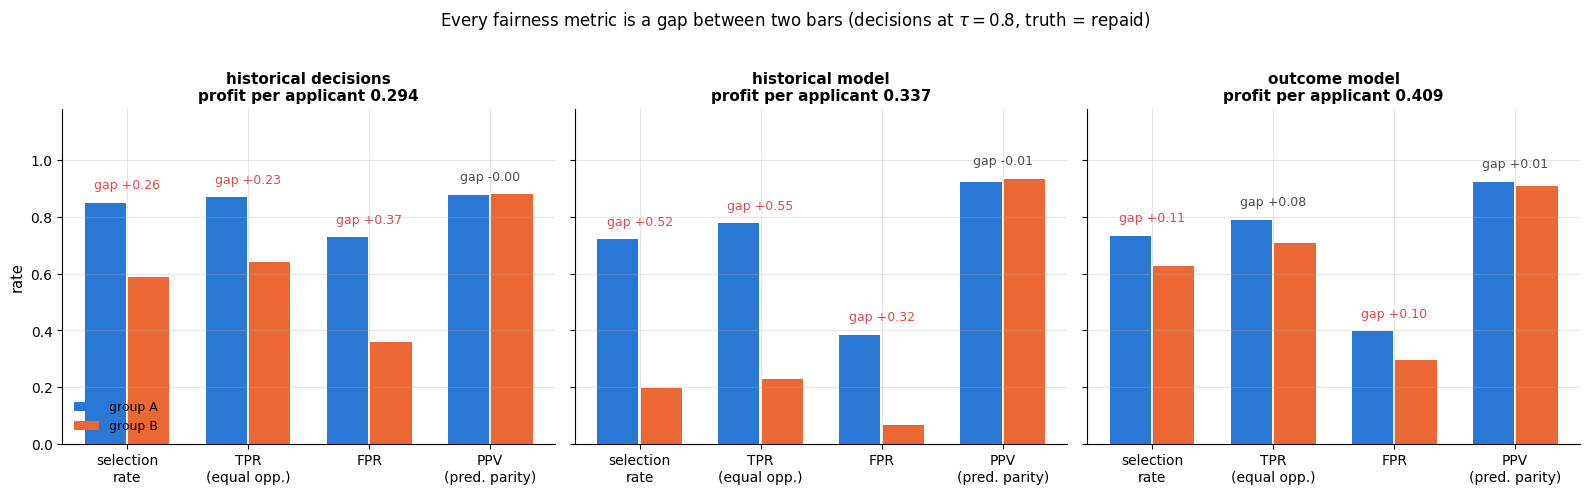

In [12]:
policies = {"historical decisions": test["approved"].to_numpy(),
            "historical model": yhat_hist,
            "outcome model": yhat_out}
shown_metrics = ["selection rate", "TPR", "FPR", "PPV"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, (name, yhat) in zip(axes, policies.items()):
    r = group_rates(y_test, yhat, g_test)
    x = np.arange(len(shown_metrics))
    for k, (g, color) in enumerate(zip(["A", "B"], [PALETTE[0], PALETTE[1]])):
        ax.bar(x + (k - 0.5) * 0.36, r.loc[g, shown_metrics].to_numpy(dtype=float),
               width=0.34, color=color, label=f"group {g}")
    for i, metric in enumerate(shown_metrics):
        a, b = float(r.loc["A", metric]), float(r.loc["B", metric])
        ax.annotate(f"gap {a - b:+.2f}", xy=(i, max(a, b) + 0.05), ha="center", fontsize=9,
                    color=PALETTE[7] if abs(a - b) > 0.1 else "0.3")
    ax.set_xticks(x)
    ax.set_xticklabels(["selection\nrate", "TPR\n(equal opp.)", "FPR", "PPV\n(pred. parity)"])
    ax.set_ylim(0, 1.18)
    ax.set_title(f"{name}\nprofit per applicant {mean_profit(y_test, yhat):.3f}", fontsize=11)
axes[0].set_ylabel("rate")
axes[0].legend(loc="lower left", fontsize=9)
fig.suptitle("Every fairness metric is a gap between two bars (decisions at $\\tau = 0.8$, truth = repaid)", y=1.02)
plt.tight_layout()
plt.show()

The gaps in the first two panels are enormous where they matter most (a TPR gap of $+0.55$
for the historical model: group A's qualified applicants are approved, group B's are not)
and *negligible* on PPV — which is exactly the configuration that made
the COMPAS argument possible: one side points at the third pair of bars, the other at the
second. The regulator's version of the first pair is a ratio rather than a difference.

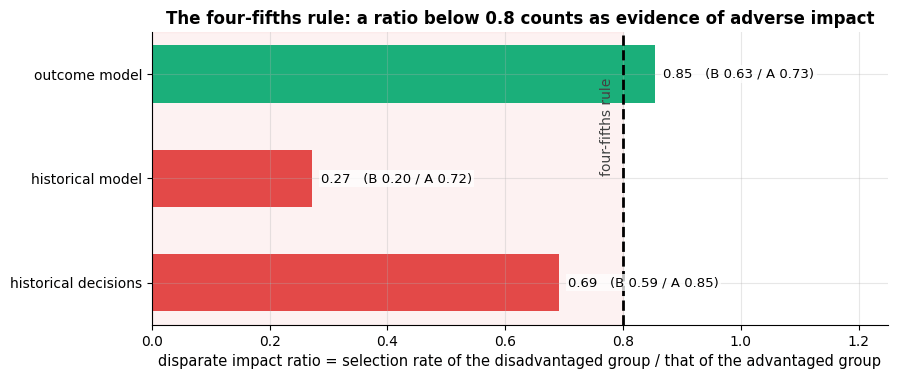

In [13]:
di_ratios, sel_rates = {}, {}
for name, yhat in policies.items():
    sel = group_rates(y_test, yhat, g_test)["selection rate"]
    di_ratios[name] = sel.min() / sel.max()
    sel_rates[name] = (sel["A"], sel["B"])

fig, ax = plt.subplots(figsize=(9.5, 3.8))
names = list(di_ratios)
values = [di_ratios[n] for n in names]
ax.barh(names, values, color=[PALETTE[7] if v < 0.8 else PALETTE[2] for v in values], height=0.55)
ax.axvspan(0, 0.8, color=PALETTE[7], alpha=0.07, zorder=0)
ax.axvline(0.8, color="black", ls="--", lw=2)
ax.text(0.785, 1.5, "four-fifths rule", ha="right", va="center", rotation=90, fontsize=10, color="0.25")
for i, n in enumerate(names):
    a, b = sel_rates[n]
    ax.text(values[i] + 0.015, i, f"{values[i]:.2f}   (B {b:.2f} / A {a:.2f})", va="center", fontsize=9.5,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5))
ax.set_xlim(0, 1.25)
ax.set_xlabel("disparate impact ratio = selection rate of the disadvantaged group / that of the advantaged group")
ax.set_title("The four-fifths rule: a ratio below 0.8 counts as evidence of adverse impact")
plt.show()

The historical model fails the four-fifths test by a wide margin; the outcome model passes
it. Note that passing is a legal *screening* device, not a certificate: a ratio of 0.85
with a TPR gap of 0.08 is still a real difference in how two groups are treated.

### 3.3 Calibration by group

The sufficiency criterion is about the *scores*. A reliability diagram per group
(notebook 7, `calibration_curve`) shows whether a predicted probability of, say, 0.7
means a 70 % repayment rate in both groups.

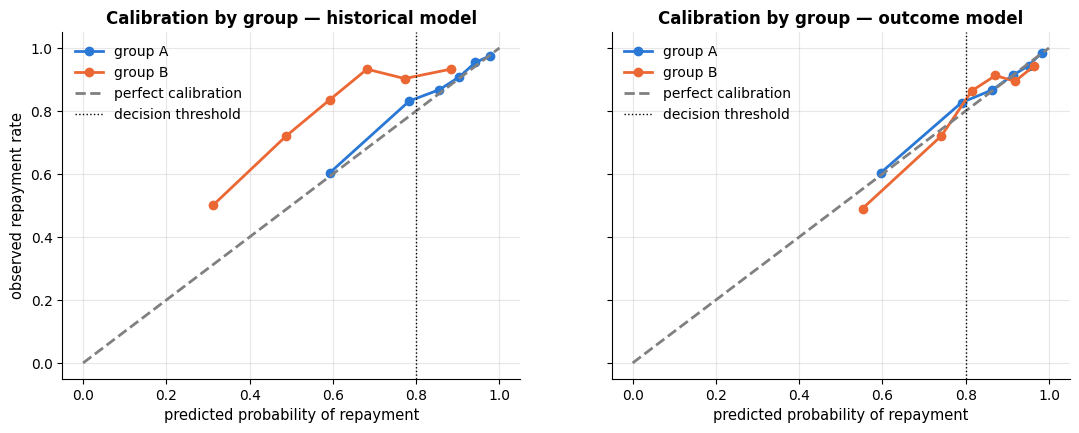

In [14]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (name, p) in zip(axes, [("historical model", p_hist), ("outcome model", p_out)]):
    for g, color in zip(["A", "B"], [PALETTE[0], PALETTE[1]]):
        m = g_test == g
        frac_pos, mean_pred = calibration_curve(y_test[m], p[m], n_bins=6, strategy="quantile")
        ax.plot(mean_pred, frac_pos, marker="o", color=color, label=f"group {g}")
    ax.plot([0, 1], [0, 1], color="gray", ls="--", label="perfect calibration")
    ax.axvline(TAU, color="black", lw=1, ls=":", label="decision threshold")
    ax.set_xlabel("predicted probability of repayment")
    ax.set_title(f"Calibration by group — {name}")
    ax.legend(loc="upper left")
axes[0].set_ylabel("observed repayment rate")
plt.show()

The outcome model is calibrated for both groups (both curves hug the diagonal). The
historical model is calibrated for group A but systematically **under-predicts** group
B: applicants of group B with a predicted repayment probability around 0.5 actually
repay more than 70 % of the time. This is the signature of label bias — the model
faithfully learned that "applications like this were denied", which is not the same as
"loans like this defaulted". Notice that the miscalibration is invisible if you evaluate
the model against the `approved` column: there it is well calibrated for everyone.

### 3.4 The impossibility results

Can we ask for a model that is calibrated within each group *and* has equal error rates?
Chouldechova (2017) shows that for any classifier, within each group, the confusion-matrix
rates satisfy the identity

$$
\mathrm{FPR} \;=\; \frac{p}{1-p}\cdot\frac{1-\mathrm{PPV}}{\mathrm{PPV}}\cdot(1-\mathrm{FNR}),
\qquad p = P(Y = 1 \mid A),
$$

which follows from counting: $\mathrm{TP} = n\,p\,(1-\mathrm{FNR})$,
$\mathrm{FP} = n\,(1-p)\,\mathrm{FPR}$ and $(1-\mathrm{PPV})/\mathrm{PPV} = \mathrm{FP}/\mathrm{TP}$.
If the base rates $p_a \ne p_b$ differ and the classifier has equal PPV in both groups
(predictive parity) and equal FNR (equal opportunity), the identity forces
$\mathrm{FPR}_a \ne \mathrm{FPR}_b$ — equalised odds fails. Kleinberg et al. (2017) prove
the analogous statement for scores: calibration by group and balance of the average score
within each outcome class are jointly achievable only if base rates are equal or the
prediction is perfect. Let us verify the identity on the outcome model and then see what
"forcing" equal PPV and FNR would imply.

In [15]:
imp = rates_out[["n", "base rate", "PPV", "FNR", "FPR"]].copy()
p, ppv, fnr = imp["base rate"], imp["PPV"], imp["FNR"]
imp["FPR from identity"] = p / (1 - p) * (1 - ppv) / ppv * (1 - fnr)
display(imp.round(3))

# hypothetical: give group B the SAME PPV and FNR as group A, keeping its own base rate
pA, ppvA, fnrA = imp.loc["A", ["base rate", "PPV", "FNR"]]
pB = imp.loc["B", "base rate"]
fpr_forced = pB / (1 - pB) * (1 - ppvA) / ppvA * (1 - fnrA)
print(f"group A: base rate {pA:.3f}, FPR {imp.loc['A', 'FPR']:.3f}")
print(f"group B with A's PPV and FNR but its own base rate {pB:.3f} would have FPR = {fpr_forced:.3f}")
print("=> with unequal base rates, predictive parity + equal opportunity => unequal FPR (equalised odds is impossible).")

,n,base rate,PPV,FNR,FPR,FPR from identity
A,1178,0.857,0.922,0.211,0.396,0.396
B,622,0.804,0.907,0.294,0.295,0.295


group A: base rate 0.857, FPR 0.396
group B with A's PPV and FNR but its own base rate 0.804 would have FPR = 0.272
=> with unequal base rates, predictive parity + equal opportunity => unequal FPR (equalised odds is impossible).


The identity is worth seeing as a curve. On the left, the false positive rate that a
classifier with group A's PPV and FNR is *forced* to have, as a function of the group's
base rate: two groups on the same curve at different base rates cannot land at the same
height. On the right, the empirical version: sweep the threshold of the outcome model and
watch the three criteria's gaps — none of the three is zero where the others are.

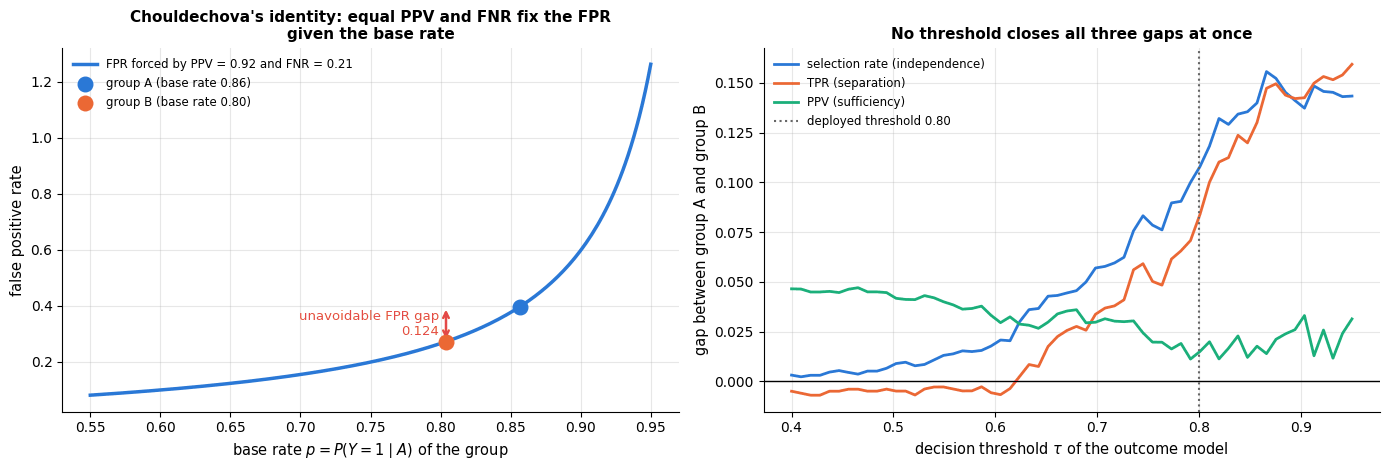

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

p_grid = np.linspace(0.55, 0.95, 200)
fpr_forced_curve = p_grid / (1 - p_grid) * (1 - ppvA) / ppvA * (1 - fnrA)
axes[0].plot(p_grid, fpr_forced_curve, lw=2.5, color=PALETTE[0],
             label=f"FPR forced by PPV = {ppvA:.2f} and FNR = {fnrA:.2f}")
axes[0].scatter([pA], [imp.loc["A", "FPR"]], color=PALETTE[0], s=110, zorder=5, label=f"group A (base rate {pA:.2f})")
axes[0].scatter([pB], [fpr_forced], color=PALETTE[1], s=110, zorder=5, label=f"group B (base rate {pB:.2f})")
axes[0].annotate("", xy=(pB, imp.loc["A", "FPR"]), xytext=(pB, fpr_forced),
                 arrowprops=dict(arrowstyle="<->", color=PALETTE[7], lw=1.8))
axes[0].text(pB - 0.005, (fpr_forced + imp.loc["A", "FPR"]) / 2,
             f"unavoidable FPR gap\n{imp.loc['A', 'FPR'] - fpr_forced:.3f}", ha="right", va="center",
             fontsize=9.5, color=PALETTE[7])
axes[0].set_xlabel("base rate $p = P(Y = 1 \\mid A)$ of the group")
axes[0].set_ylabel("false positive rate")
axes[0].set_title("Chouldechova's identity: equal PPV and FNR fix the FPR\ngiven the base rate", fontsize=11)
axes[0].legend(fontsize=8.5, loc="upper left")

sweep_taus = np.linspace(0.40, 0.95, 60)
gaps = {"selection rate (independence)": [], "TPR (separation)": [], "PPV (sufficiency)": []}
for t in sweep_taus:
    r = group_rates(y_test, (p_out >= t).astype(int), g_test)
    gaps["selection rate (independence)"].append(float(r.loc["A", "selection rate"] - r.loc["B", "selection rate"]))
    gaps["TPR (separation)"].append(float(r.loc["A", "TPR"] - r.loc["B", "TPR"]))
    gaps["PPV (sufficiency)"].append(float(r.loc["A", "PPV"] - r.loc["B", "PPV"]))
for (label, values), color in zip(gaps.items(), PALETTE):
    axes[1].plot(sweep_taus, values, lw=2, color=color, label=label)
axes[1].axhline(0, color="black", lw=1)
axes[1].axvline(TAU, color="0.4", ls=":", lw=1.5, label=f"deployed threshold {TAU:.2f}")
axes[1].set_xlabel("decision threshold $\\tau$ of the outcome model")
axes[1].set_ylabel("gap between group A and group B")
axes[1].set_title("No threshold closes all three gaps at once", fontsize=11)
axes[1].legend(fontsize=8.5)
plt.tight_layout()
plt.show()

In the right-hand panel the three gaps are minimised at *different* thresholds: the TPR gap
crosses zero near $\tau \approx 0.62$, where the PPV gap is around $0.03$ — more than twice
its own minimum; at the deployed $\tau = 0.8$ the PPV gap is at its smallest while the
selection-rate and TPR gaps have grown to about $0.10$ and $0.08$; and the PPV gap is
largest of all at the *lowest* thresholds, where the other two are near zero. There is no
vertical line that makes the three curves meet at zero — which is the impossibility result,
seen from the operating-point side.

> **Why it matters.** The COMPAS dispute was exactly this: ProPublica measured
> separation (unequal FPR/FNR), the vendor measured sufficiency (equal PPV), and with a
> re-arrest base rate that differs between groups both were right. The impossibility
> theorem does not say fairness is hopeless; it says that *choosing* a criterion is a
> substantive decision that has to be argued for in the context of the application — see
> section 4.4 — and cannot be delegated to a metric library.

### 3.5 Individual and counterfactual fairness

Group metrics compare averages; two very different individuals can be treated
differently without moving any of them. **Individual fairness** (Dwork et al., 2012)
asks instead that *similar individuals be treated similarly*: the decision function
should be Lipschitz with respect to a task-specific similarity metric $d$,
$\,|f(\mathbf{x}) - f(\mathbf{x}')| \le L\, d(\mathbf{x}, \mathbf{x}')$. The difficulty is
that defining $d$ (which differences between two applicants *should* matter?) is the
whole problem in disguise. **Counterfactual fairness** (Kusner et al., 2017) uses a
causal model: a decision is fair for an individual if it would have been the same in the
counterfactual world where only the protected attribute (and its causal descendants)
changed. In the loan data, income is a descendant of group in the generating process, so
a counterfactually fair model would have to discount the part of the income gap that is
*caused* by group membership — a judgement that requires a causal graph, not just data.

## 4. Interventions

Interventions are usually classified by *where* in the pipeline they act:

| Stage | Idea | Examples |
|---|---|---|
| **Pre-processing** | change the training data | remove proxies, reweigh or resample, learn "fair" representations |
| **In-processing** | change the learning objective | fairness constraints or regularisers, reductions to cost-sensitive learning |
| **Post-processing** | change the decisions | group-specific thresholds, randomised decisions on the ROC hull |

### 4.1 Pre-processing I: unawareness and its limits

The most common intervention is also the weakest: delete the protected attribute. Let us
train the historical model on three feature sets and watch what happens.

In [17]:
feature_sets = {
    "all features (incl. group, zip)": (numeric, categorical + ["group", "zip_prefix"]),
    "without group (zip kept)": (numeric, categorical + ["zip_prefix"]),
    "without group and zip": (numeric, categorical),
}
rows = []
for name, (num_cols, cat_cols) in feature_sets.items():
    cols = num_cols + cat_cols
    m = make_model(num_cols, cat_cols).fit(train[cols], train["approved"])
    yhat = (m.predict_proba(test[cols])[:, 1] >= TAU).astype(int)
    fs = fairness_summary(group_rates(y_test, yhat, g_test))
    rows.append({"features": name, "profit": mean_profit(y_test, yhat),
                 "DP difference": fs["demographic parity difference"], "DI ratio": fs["disparate impact ratio"],
                 "EO difference": fs["equal opportunity difference"]})
unaware = pd.DataFrame(rows).set_index("features")
unaware.round(3)

,profit,DP difference,DI ratio,EO difference
features,,,,
"all features (incl. group, zip)",0.337,0.525,0.272,0.549
without group (zip kept),0.336,0.526,0.270,0.551
without group and zip,0.339,0.170,0.700,0.167


Dropping `group` changes nothing: `zip_prefix` carries the same information and the model
uses it instead. Dropping both removes the *direct* channel in this synthetic data, and
the gaps shrink — but they do not vanish, because income still correlates with group. In
real data the situation is worse: dozens of weakly informative features jointly
reconstruct the attribute. A useful diagnostic is a **proxy audit**: train a classifier to
predict the protected attribute *from the remaining features*. If it succeeds, the
features contain the attribute whether or not you deleted the column.

In [18]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve

is_B = (loans["group"] == "B").to_numpy().astype(int)
proxy_scores = {}
for name, (num_cols, cat_cols) in list(feature_sets.items())[1:]:
    cols = num_cols + cat_cols
    s = cross_val_predict(make_model(num_cols, cat_cols), loans[cols], is_B, cv=5, method="predict_proba")[:, 1]
    proxy_scores[name] = s
    print(f"predicting the group from '{name}': cross-validated AUC = {roc_auc_score(is_B, s):.3f}")

predicting the group from 'without group (zip kept)': cross-validated AUC = 1.000
predicting the group from 'without group and zip': cross-validated AUC = 0.660


Three pictures tell the whole story of unawareness: the disparity barely moves when the
protected column is deleted (left), because the group can still be read off the remaining
features — perfectly while the postcode is there, and well above chance even without it
(middle and right).

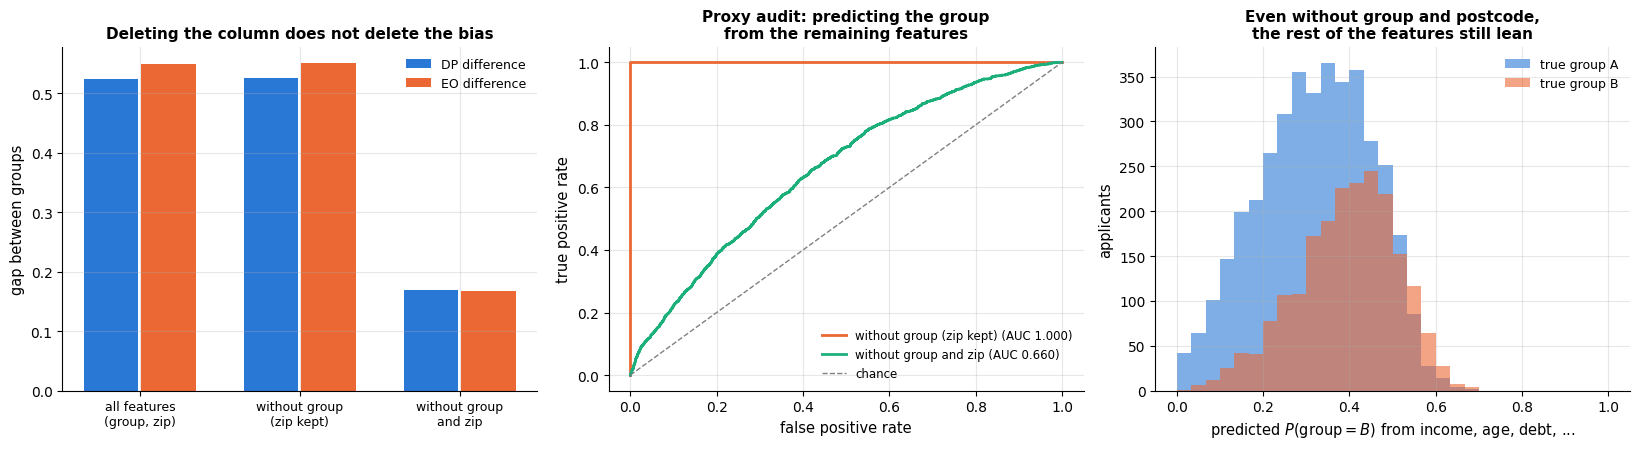

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))

x = np.arange(len(unaware))
labels = ["all features\n(group, zip)", "without group\n(zip kept)", "without group\nand zip"]
for k, (metric, color) in enumerate(zip(["DP difference", "EO difference"], [PALETTE[0], PALETTE[1]])):
    axes[0].bar(x + (k - 0.5) * 0.36, unaware[metric].to_numpy(), width=0.34, color=color, label=metric)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_ylabel("gap between groups")
axes[0].set_title("Deleting the column does not delete the bias", fontsize=11)
axes[0].legend(fontsize=9)

for (name, s), color in zip(proxy_scores.items(), [PALETTE[1], PALETTE[2]]):
    fpr, tpr, _ = roc_curve(is_B, s)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC {roc_auc_score(is_B, s):.3f})")
axes[1].plot([0, 1], [0, 1], color="gray", ls="--", lw=1, label="chance")
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].set_title("Proxy audit: predicting the group\nfrom the remaining features", fontsize=11)
axes[1].legend(fontsize=8.5, loc="lower right")

s_residual = proxy_scores["without group and zip"]
prob_bins = np.linspace(0, 1, 31)
for g, color in zip([0, 1], [PALETTE[0], PALETTE[1]]):
    axes[2].hist(s_residual[is_B == g], bins=prob_bins, alpha=0.6, color=color, label=f"true group {'B' if g else 'A'}")
axes[2].set_xlabel("predicted $P(\\mathrm{group} = B)$ from income, age, debt, ...")
axes[2].set_ylabel("applicants")
axes[2].set_title("Even without group and postcode,\nthe rest of the features still lean", fontsize=11)
axes[2].legend(fontsize=9)
plt.tight_layout()
plt.show()

### 4.2 Pre-processing II: reweighing

Reweighing (Kamiran & Calders, 2012) keeps the data but changes the *weights* so that in
the weighted training set the label is independent of the group. If the label were
independent of the group, the expected count of (group $a$, label $y$) pairs would be
$n \cdot P(A=a)P(Y=y)$; the observed count is $n \cdot P(A=a, Y=y)$. Assigning every
training sample the weight

$$
w(a, y) \;=\; \frac{P(A=a)\,P(Y=y)}{P(A=a,\,Y=y)}
$$

makes the weighted joint distribution factorise. Under-represented combinations
(group B *and* approved) are up-weighted, over-represented ones (group B *and* denied)
down-weighted. The classifier is then trained with `sample_weight` — every scikit-learn
estimator that supports weights can be used unchanged.

In [20]:
def reweighing_weights(group, y):
    group, y = np.asarray(group), np.asarray(y)
    w = np.empty(len(y))
    for a in np.unique(group):
        for label in np.unique(y):
            m = (group == a) & (y == label)
            w[m] = np.mean(group == a) * np.mean(y == label) / np.mean(m)
    return w

w_train = reweighing_weights(train["group"], train["approved"])
weight_table = pd.DataFrame({"group": train["group"], "approved": train["approved"], "weight": w_train}) \
    .drop_duplicates().sort_values(["group", "approved"]).set_index(["group", "approved"])
display(weight_table.round(3))

rw_model = make_model(numeric, categorical + ["group", "zip_prefix"])
rw_model.fit(train[all_features], train["approved"], lr__sample_weight=w_train)
p_rw = rw_model.predict_proba(test[all_features])[:, 1]
yhat_rw = (p_rw >= TAU).astype(int)
rates_rw = group_rates(y_test, yhat_rw, g_test)
print(f"reweighed historical model: profit {mean_profit(y_test, yhat_rw):.3f}")
display(pd.DataFrame({"historical model": fairness_summary(rates_hist), "reweighed": fairness_summary(rates_rw)}).round(3))

weight
group approved        
A     0          1.500
      1          0.910
B     0          0.613
      1          1.232

reweighed historical model: profit 0.343


,historical model,reweighed
demographic parity difference,0.525,0.098
disparate impact ratio,0.272,0.822
equal opportunity difference,0.549,0.084
equalised odds difference,0.549,0.084
predictive parity difference,0.011,0.015


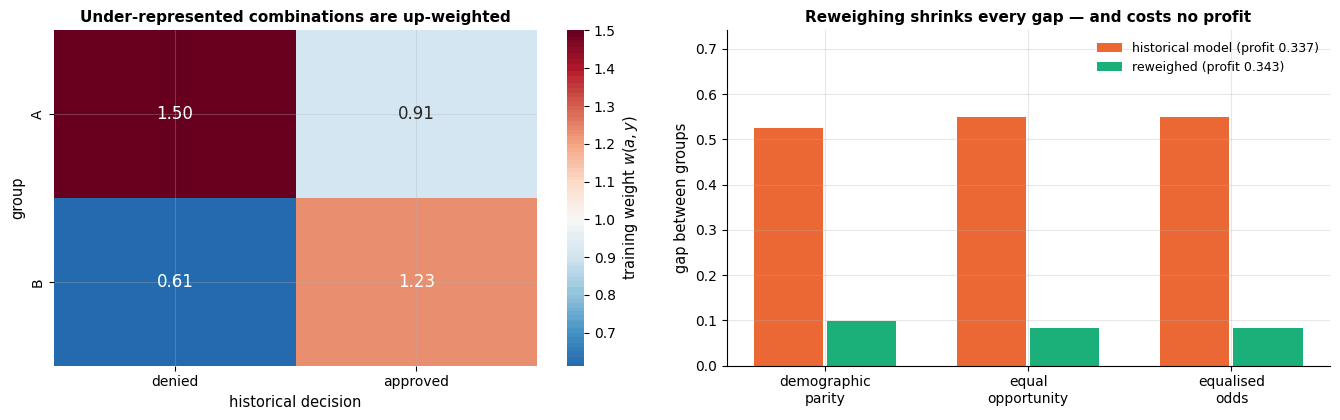

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.3))
w_matrix = weight_table["weight"].unstack()
sns.heatmap(w_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=1.0, ax=axes[0],
            cbar_kws={"label": "training weight $w(a, y)$"}, annot_kws={"fontsize": 12})
axes[0].set_title("Under-represented combinations are up-weighted", fontsize=11)
axes[0].set_xlabel("historical decision")
axes[0].set_xticklabels(["denied", "approved"])
axes[0].set_ylabel("group")

gap_names = ["demographic parity difference", "equal opportunity difference", "equalised odds difference"]
before, after = fairness_summary(rates_hist), fairness_summary(rates_rw)
x = np.arange(len(gap_names))
axes[1].bar(x - 0.18, [before[m] for m in gap_names], width=0.34, color=PALETTE[1],
            label=f"historical model (profit {mean_profit(y_test, yhat_hist):.3f})")
axes[1].bar(x + 0.18, [after[m] for m in gap_names], width=0.34, color=PALETTE[2],
            label=f"reweighed (profit {mean_profit(y_test, yhat_rw):.3f})")
axes[1].set_xticks(x)
axes[1].set_xticklabels(["demographic\nparity", "equal\nopportunity", "equalised\nodds"])
axes[1].set_ylabel("gap between groups")
axes[1].set_ylim(0, max(before[m] for m in gap_names) * 1.35)     # headroom so the legend never covers a bar
axes[1].set_title("Reweighing shrinks every gap — and costs no profit", fontsize=11)
axes[1].legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

Reweighing closes most of the selection-rate gap while still training on the biased
label and all the features. It is cheap, model-agnostic and easy to explain — and it
targets *independence* (demographic parity), so it does not by itself guarantee equal
error rates.

### 4.3 In-processing: constraints and the `fairlearn` toolkit

In-processing methods change the objective: a constraint or penalty on a fairness
statistic is added to the loss, or — the *reductions* approach of Agarwal et al. (2018) —
the constrained problem is turned into a sequence of cost-sensitive classification
problems that any standard learner can solve. The latter is implemented as
`ExponentiatedGradient` in the `fairlearn` library (Bird et al., 2020). `fairlearn` is
optional in this course; when it is installed, the cell below cross-checks our
from-scratch metrics with its `MetricFrame`.

In [22]:
try:
    from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate
    HAS_FAIRLEARN = True
except ImportError:
    HAS_FAIRLEARN = False
    print("fairlearn is not installed — skipping the cross-check (pip install fairlearn).")

if HAS_FAIRLEARN:
    mf = MetricFrame(metrics={"selection rate": selection_rate, "TPR": true_positive_rate, "FPR": false_positive_rate},
                     y_true=y_test, y_pred=yhat_hist, sensitive_features=g_test)
    display(mf.by_group.round(3))
    print("differences between groups (fairlearn):")
    print(mf.difference().round(3))
    print("our implementation:")
    print(fairness_summary(rates_hist).round(3))

fairlearn is not installed — skipping the cross-check (pip install fairlearn).


### 4.4 Post-processing: group-specific thresholds (Hardt et al., 2016)

Post-processing takes the trained score as given and changes only the decision rule. For
*equal opportunity*, the construction is simple: choose a separate threshold $\tau_a$ for
each group so that the true positive rates coincide,
$P(R \ge \tau_a \mid Y=1, A=a) = P(R \ge \tau_b \mid Y=1, A=b)$. For every target TPR
$t$ there is one such pair of thresholds; among all pairs we pick the one that maximises
the bank's profit. (For full *equalised odds* — equal TPR *and* FPR — a single threshold
per group is generally not enough; Hardt et al. show that the achievable points are the
intersection of the groups' ROC convex hulls, reached by *randomising* between two
thresholds. Exercise 3 implements it.)

Thresholds are parameters fitted to data, so they are chosen on the *training*
applicants — whose repayment outcome the historical model never saw — and evaluated on
the test set, like everything else.

In [23]:
def threshold_for_tpr(scores, y_true, target_tpr):
    """Largest threshold at which the true positive rate is at least `target_tpr`."""
    positives = np.sort(scores[np.asarray(y_true) == 1])
    k = int(np.ceil((1 - target_tpr) * len(positives)))          # number of positives allowed below the threshold
    return positives[min(k, len(positives) - 1)]

def equal_opportunity_thresholds(scores, y_true, group, target_tpr):
    """One threshold per group such that every group reaches the same true positive rate."""
    scores, y_true, group = (np.asarray(a) for a in (scores, y_true, group))
    return {g: threshold_for_tpr(scores[group == g], y_true[group == g], target_tpr) for g in np.unique(group)}

def apply_thresholds(scores, group, thresholds):
    scores, group = np.asarray(scores), np.asarray(group)
    return np.array([int(s >= thresholds[g]) for s, g in zip(scores, group)])

# scores and outcomes of the TRAINING applicants (the outcome label was not used to fit hist_model)
p_hist_train = hist_model.predict_proba(train[all_features])[:, 1]
y_train_out, g_train = train["repaid"].to_numpy(), train["group"].to_numpy()

targets = np.linspace(0.3, 1.0, 71)
train_profits = [mean_profit(y_train_out, apply_thresholds(p_hist_train, g_train,
                             equal_opportunity_thresholds(p_hist_train, y_train_out, g_train, t))) for t in targets]
best_t = targets[int(np.argmax(train_profits))]
taus_eo = equal_opportunity_thresholds(p_hist_train, y_train_out, g_train, best_t)
yhat_eo = apply_thresholds(p_hist, g_test, taus_eo)
rates_eo = group_rates(y_test, yhat_eo, g_test)
print(f"most profitable equal-opportunity operating point (chosen on the training set): target TPR = {best_t:.2f}, "
      f"tau_A = {taus_eo['A']:.3f}, tau_B = {taus_eo['B']:.3f}")
print(f"test profit per applicant: {mean_profit(y_test, yhat_eo):.3f}  (single threshold {TAU}: {mean_profit(y_test, yhat_hist):.3f})")
display(rates_eo[["selection rate", "TPR", "FPR", "PPV"]].round(3))

most profitable equal-opportunity operating point (chosen on the training set): target TPR = 0.77, tau_A = 0.816, tau_B = 0.535
test profit per applicant: 0.399  (single threshold 0.8: 0.337)


,selection rate,TPR,FPR,PPV
A,0.693,0.749,0.355,0.926
B,0.686,0.764,0.369,0.895


The historical model's scores are too low for group B (section 3.3), and the post-processed
rule compensates with a much lower threshold for that group; on the test set the two
true positive rates agree up to sampling noise. Two things are worth noticing. First,
profit went *up*: the single-threshold rule was leaving qualified group-B applicants (and
their interest payments) on the table. Second, the fix requires the protected attribute
*at decision time* — which is sometimes illegal (disparate treatment) even when the
resulting disparate impact is what the law wants to prevent (Barocas, Hardt & Narayanan,
2023, ch. 5). The ROC curves per group show the geometry.

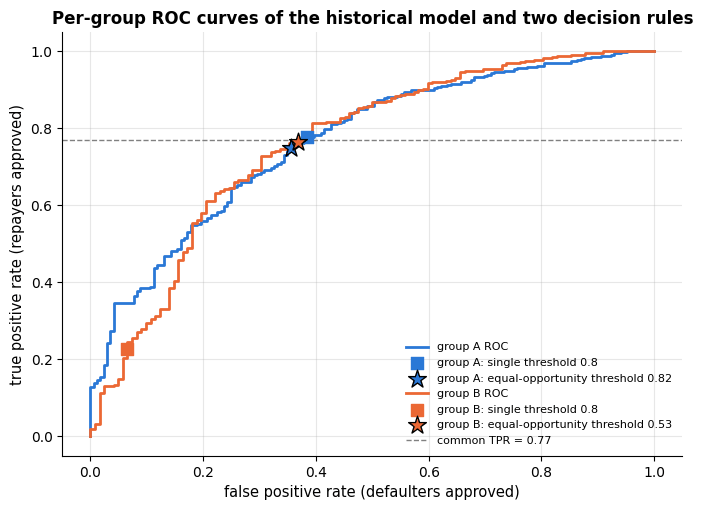

In [24]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for g, color in zip(["A", "B"], [PALETTE[0], PALETTE[1]]):
    m = g_test == g
    fpr, tpr, thr = roc_curve(y_test[m], p_hist[m])
    ax.plot(fpr, tpr, color=color, label=f"group {g} ROC")
    r_single = rates_hist.loc[g]
    ax.scatter(r_single["FPR"], r_single["TPR"], color=color, marker="s", s=70, zorder=5,
               label=f"group {g}: single threshold {TAU}")
    r_eo = rates_eo.loc[g]
    ax.scatter(r_eo["FPR"], r_eo["TPR"], color=color, marker="*", s=180, zorder=6, edgecolor="black",
               label=f"group {g}: equal-opportunity threshold {taus_eo[g]:.2f}")
ax.axhline(best_t, color="gray", ls="--", lw=1, label=f"common TPR = {best_t:.2f}")
ax.set_xlabel("false positive rate (defaulters approved)")
ax.set_ylabel("true positive rate (repayers approved)")
ax.set_title("Per-group ROC curves of the historical model and two decision rules")
ax.legend(fontsize=8, loc="lower right")
plt.show()

The two ROC curves are close together — the model *ranks* applicants of both groups about
equally well — but a single threshold lands on very different points of them, because the
scores are shifted. Drawing the two cut-offs on the score distributions themselves shows
what post-processing actually does: it does not touch the model, only the place where the
line is drawn.

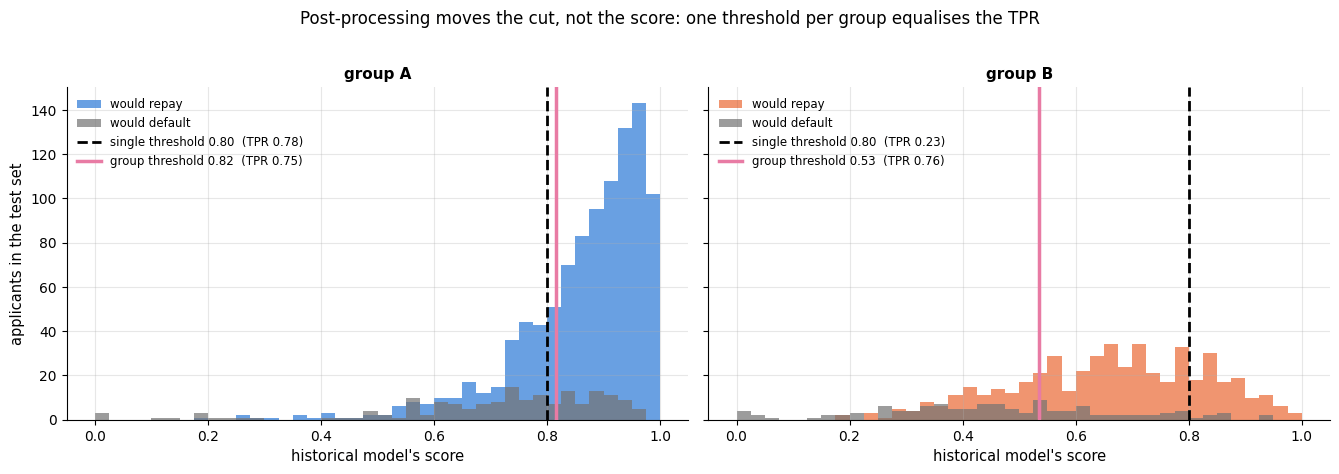

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), sharey=True)
for ax, g, color in zip(axes, ["A", "B"], [PALETTE[0], PALETTE[1]]):
    m = g_test == g
    ax.hist(p_hist[m][y_test[m] == 1], bins=score_bins, color=color, alpha=0.7, label="would repay")
    ax.hist(p_hist[m][y_test[m] == 0], bins=score_bins, color="0.45", alpha=0.7, label="would default")
    ax.axvline(TAU, color="black", ls="--", lw=2,
               label=f"single threshold {TAU:.2f}  (TPR {rates_hist.loc[g, 'TPR']:.2f})")
    ax.axvline(taus_eo[g], color=PALETTE[4], ls="-", lw=2.5,
               label=f"group threshold {taus_eo[g]:.2f}  (TPR {rates_eo.loc[g, 'TPR']:.2f})")
    ax.set_xlabel("historical model's score")
    ax.set_title(f"group {g}", fontsize=11)
    ax.legend(fontsize=8.5, loc="upper left")
axes[0].set_ylabel("applicants in the test set")
fig.suptitle("Post-processing moves the cut, not the score: one threshold per group equalises the TPR", y=1.02)
plt.tight_layout()
plt.show()

For group A the two lines almost coincide; for group B the group-specific threshold sits
far to the left, where most of that group's would-be repayers are. The price is visible
too: more of group B's would-be defaulters now fall to the right of the line, which is why
the FPRs in the table above are also equalised upwards.

### 4.5 The accuracy–fairness trade-off

Equalising opportunity exactly is one point on a curve. For each *allowed* TPR gap
$\delta$ we can ask: what is the highest profit achievable with thresholds
$(\tau_A, \tau_B)$ such that $|\mathrm{TPR}_A - \mathrm{TPR}_B| \le \delta$? A grid
search over threshold pairs on the training set answers this; evaluating each winning
pair on the test set traces the **Pareto front** between the two objectives — the picture
to bring to the meeting where the trade-off is decided.

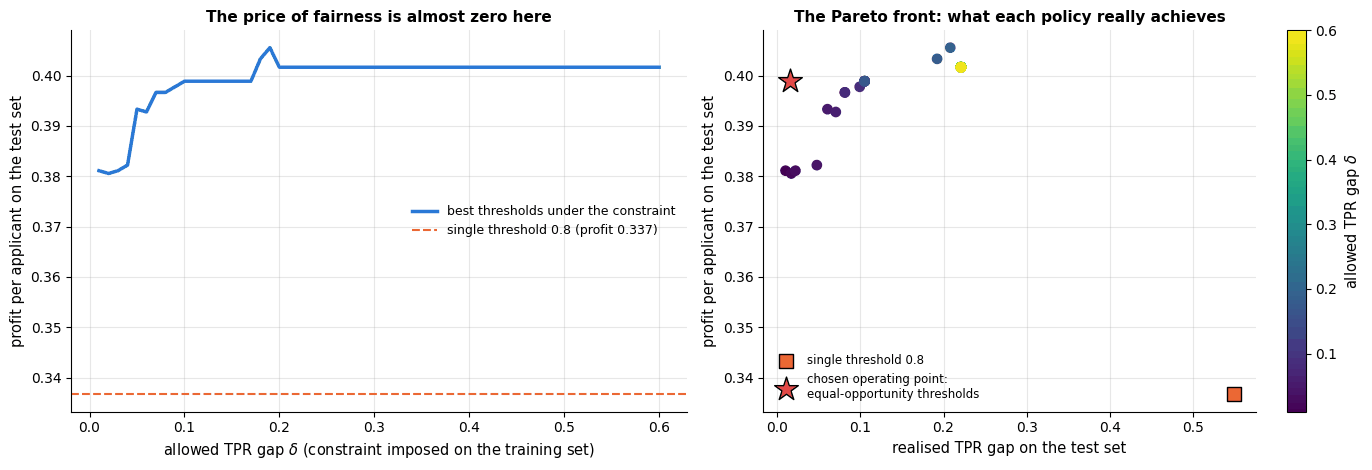

profit with a TPR gap of at most 0.01: 0.381;  with no constraint: 0.402 (realised test gap 0.221)


In [26]:
def group_curves(scores, y_true, grid):
    """TPR and total profit contribution of one group for every threshold in `grid`."""
    pred = scores[None, :] >= grid[:, None]                       # (n_thresholds, n_samples)
    tpr = pred[:, y_true == 1].mean(axis=1)
    profit = GAIN * pred[:, y_true == 1].sum(axis=1) - LOSS * pred[:, y_true == 0].sum(axis=1)
    return tpr, profit

grid = np.quantile(p_hist_train, np.linspace(0.005, 0.995, 150))
mA, mB = g_train == "A", g_train == "B"
tpr_A, prof_A = group_curves(p_hist_train[mA], y_train_out[mA], grid)
tpr_B, prof_B = group_curves(p_hist_train[mB], y_train_out[mB], grid)
train_profit = (prof_A[:, None] + prof_B[None, :]) / len(train)      # every (tau_A, tau_B) pair
train_gap = np.abs(tpr_A[:, None] - tpr_B[None, :])

deltas = np.linspace(0.01, 0.6, 60)                                # allowed TPR gap (the grid cannot hit exactly 0)
front_profit, front_gap = [], []
for d in deltas:
    i, j = np.unravel_index(np.argmax(np.where(train_gap <= d, train_profit, -np.inf)), train_profit.shape)
    yhat = apply_thresholds(p_hist, g_test, {"A": grid[i], "B": grid[j]})
    front_profit.append(mean_profit(y_test, yhat))
    front_gap.append(fairness_summary(group_rates(y_test, yhat, g_test))["equal opportunity difference"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].plot(deltas, front_profit, lw=2.5, color=PALETTE[0],
             label="best thresholds under the constraint")
axes[0].axhline(mean_profit(y_test, yhat_hist), color=PALETTE[1], ls="--", lw=1.5,
                label=f"single threshold {TAU} (profit {mean_profit(y_test, yhat_hist):.3f})")
axes[0].set_xlabel("allowed TPR gap $\\delta$ (constraint imposed on the training set)")
axes[0].set_ylabel("profit per applicant on the test set")
axes[0].set_title("The price of fairness is almost zero here", fontsize=11)
axes[0].legend(fontsize=9, loc="center right")

sc = axes[1].scatter(front_gap, front_profit, c=deltas, cmap="viridis", s=45, zorder=3)
fig.colorbar(sc, ax=axes[1], label="allowed TPR gap $\\delta$")
axes[1].scatter([fairness_summary(rates_hist)["equal opportunity difference"]], [mean_profit(y_test, yhat_hist)],
                color=PALETTE[1], s=110, marker="s", zorder=5, edgecolor="black", label=f"single threshold {TAU}")
axes[1].scatter([fairness_summary(rates_eo)["equal opportunity difference"]], [mean_profit(y_test, yhat_eo)],
                color=PALETTE[7], marker="*", s=320, zorder=6, edgecolor="black",
                label="chosen operating point:\nequal-opportunity thresholds")
axes[1].set_xlabel("realised TPR gap on the test set")
axes[1].set_ylabel("profit per applicant on the test set")
axes[1].set_title("The Pareto front: what each policy really achieves", fontsize=11)
axes[1].legend(fontsize=8.5, loc="lower left")
plt.tight_layout()
plt.show()
print(f"profit with a TPR gap of at most 0.01: {front_profit[0]:.3f};  with no constraint: {front_profit[-1]:.3f} "
      f"(realised test gap {front_gap[-1]:.3f})")

For this model the front is almost flat: relaxing the constraint all the way buys about
$0.02$ per applicant over the strictest setting (and the unconstrained optimum still leaves
a realised TPR gap above $0.2$), so *closing the gap almost entirely costs about five per
cent of the profit* — the equal-opportunity point marked with a star gives up less than
$0.01$. The single-threshold rule, by contrast, sits far below the whole front, because it
applies one cut-off to scores that mean different things in the two groups: it is neither
fair nor profitable. In other problems the front slopes steeply and the decision is
genuinely costly; either way, the curve — not a single number — is the honest summary.

### 4.6 Choosing a definition with stakeholders

No metric is right in general. Some guidance that practitioners converge on:

| Situation | Reasonable primary criterion | Why |
|---|---|---|
| Label is a past *decision* you distrust | independence (demographic parity), reweighing | the error rates are computed against a corrupted label anyway |
| Label is a reliable *outcome*; the intervention is a benefit (a loan, a scholarship, extra care) | equal opportunity (equal TPR) | the harm is denying a qualified person |
| The intervention is punitive (detention, fraud investigation) | equal FPR, or equalised odds | the harm is wrongly targeting an innocent person |
| A human uses the score to make many decisions | calibration by group | the score must mean the same thing for everyone |
| Any of the above | look at *all* the metrics, report them, and explain the choice | the impossibility theorem guarantees the others will not be zero |

And the decision belongs to the people who bear the consequences and to the institution
that answers for them — with the data scientist supplying the curve, the definitions and
their implications, in language the room understands.

## 5. Privacy

### 5.1 Personal data and the law

In the European Union (and in the growing list of jurisdictions with similar laws), the
General Data Protection Regulation (GDPR, Regulation (EU) 2016/679) governs any
processing of *personal data* — information relating to an identifiable person. The
principles that matter most for ML projects are:

- **Lawful basis and purpose limitation**: data collected for one purpose (billing) may
  not silently be reused for another (training a churn model) without a legal basis.
- **Data minimisation and storage limitation**: collect and keep only what the purpose
  requires; "we might need it for a model some day" is not a purpose.
- **Special categories** (ethnicity, health, religion, sexual orientation, biometrics …)
  need an explicit exemption to process at all — and, as section 4 showed, are often
  needed precisely to *audit* for discrimination, which creates a real tension.
- **Rights of the data subject**: access, rectification, erasure ("right to be
  forgotten" — hard to honour for a trained model), and Article 22's limits on
  *solely automated* decisions with legal or similarly significant effects, which
  requires at least the right to human intervention. Whether the "meaningful information
  about the logic involved" that Articles 13–15 require amounts to a *right to an
  explanation* of individual decisions is debated (Wachter, Mittelstadt & Floridi, 2017),
  but the practical direction is clear: keep the model explainable (notebook 17) and
  document it (notebook 18).

### 5.2 Anonymisation and its limits

Removing names and identifiers is not anonymisation. Sweeney (2002) showed that about
87 % of the US population is uniquely identified by the combination of five-digit ZIP
code, birth date and sex — three "harmless" *quasi-identifiers* — and famously
re-identified a governor's medical records from a supposedly anonymised hospital release;
linking a release with any public dataset that shares such columns does the rest.
**$k$-anonymity** (Sweeney, 2002) asks that every combination of quasi-identifier values
in a release be shared by at least $k$ records; it is achieved by *generalising* (age →
age bracket) and *suppressing* values. Let us measure it on the loan data.

In [27]:
def k_anonymity(df, quasi_identifiers):
    """Size of the group of identical quasi-identifier values that each row belongs to."""
    return df.groupby(quasi_identifiers)[quasi_identifiers[0]].transform("size")

k_sets = {}
for qi in [["age", "zip_prefix"], ["age", "zip_prefix", "education"], ["age", "zip_prefix", "education", "purpose"]]:
    k_sets[" + ".join(qi)] = k_anonymity(loans, qi).to_numpy()

# generalising age to 10-year brackets restores k-anonymity for most rows
coarse = loans.assign(age_bracket=(loans["age"] // 10) * 10)
k_sets["age BRACKET + zip_prefix + education + purpose"] = \
    k_anonymity(coarse, ["age_bracket", "zip_prefix", "education", "purpose"]).to_numpy()

for name, k in k_sets.items():
    print(f"{name:48s} unique rows: {np.mean(k == 1):5.1%}   rows with k < 5: {np.mean(k < 5):5.1%}")

age + zip_prefix                                 unique rows:  0.4%   rows with k < 5:  2.6%
age + zip_prefix + education                     unique rows:  4.3%   rows with k < 5: 20.8%
age + zip_prefix + education + purpose           unique rows: 28.7%   rows with k < 5: 88.3%
age BRACKET + zip_prefix + education + purpose   unique rows:  1.8%   rows with k < 5:  9.2%


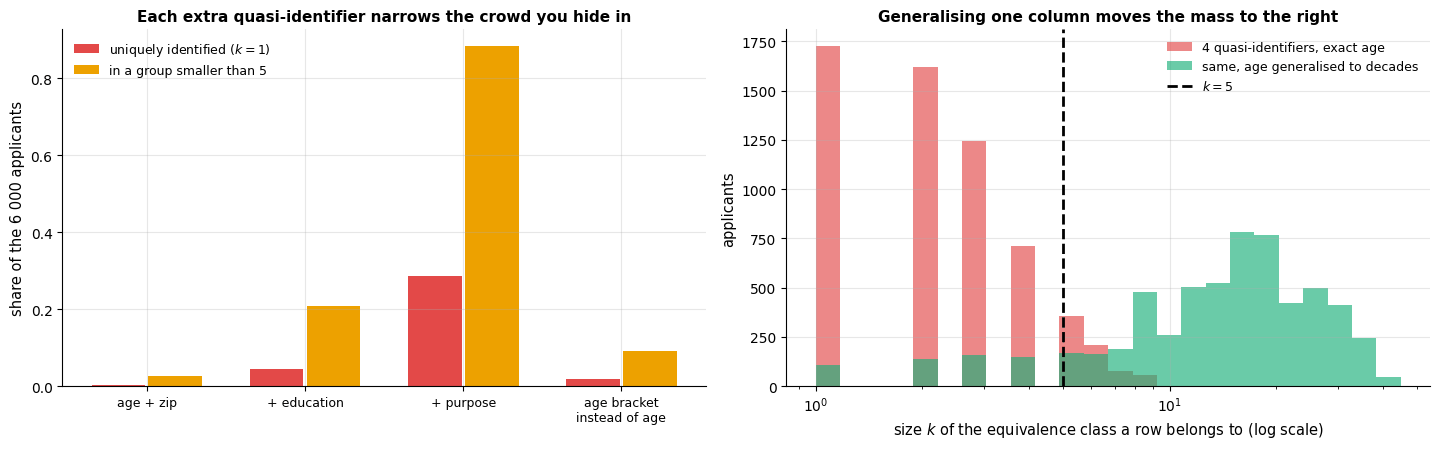

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6))
labels = ["age + zip", "+ education", "+ purpose", "age bracket\ninstead of age"]
x = np.arange(len(k_sets))
unique_share = [np.mean(k == 1) for k in k_sets.values()]
small_share = [np.mean(k < 5) for k in k_sets.values()]
axes[0].bar(x - 0.18, unique_share, width=0.34, color=PALETTE[7], label="uniquely identified ($k = 1$)")
axes[0].bar(x + 0.18, small_share, width=0.34, color=PALETTE[3], label="in a group smaller than 5")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_ylabel("share of the 6 000 applicants")
axes[0].set_title("Each extra quasi-identifier narrows the crowd you hide in", fontsize=11)
axes[0].legend(fontsize=9)

edges = np.logspace(0, np.log10(max(k_sets["age + zip_prefix + education + purpose"].max(),
                                    k_sets["age BRACKET + zip_prefix + education + purpose"].max())), 25)
for (name, color, label) in [("age + zip_prefix + education + purpose", PALETTE[7], "4 quasi-identifiers, exact age"),
                             ("age BRACKET + zip_prefix + education + purpose", PALETTE[2], "same, age generalised to decades")]:
    axes[1].hist(k_sets[name], bins=edges, alpha=0.65, color=color, label=label)
axes[1].axvline(5, color="black", ls="--", lw=2, label="$k = 5$")
axes[1].set_xscale("log")
axes[1].set_xlabel("size $k$ of the equivalence class a row belongs to (log scale)")
axes[1].set_ylabel("applicants")
axes[1].set_title("Generalising one column moves the mass to the right", fontsize=11)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

Four plausible quasi-identifiers already single out more than a quarter of the
applicants in a table of 6 000 rows, and leave almost 90 % of them in groups smaller
than five. Generalising age to brackets repairs most of it — at a cost in the precision of
any analysis on the released data. And even a $k$-anonymous release leaks if all $k$
members share the sensitive value (*homogeneity*), or if the attacker has background
knowledge — which motivated the mathematically stronger notion that follows.

### 5.3 Differential privacy

Differential privacy (Dwork, McSherry, Nissim & Smith, 2006; Dwork & Roth, 2014) changes
the question from "is this dataset anonymous?" to "how much can the *output* of an
analysis depend on any one person?". A randomised mechanism $\mathcal{M}$ is
**$\varepsilon$-differentially private** if for all pairs of datasets $D, D'$ that differ
in one record and all sets of outputs $S$,

$$
P\big(\mathcal{M}(D) \in S\big) \;\le\; e^{\varepsilon}\, P\big(\mathcal{M}(D') \in S\big).
$$

Whatever an observer concludes from the output, they would have concluded almost the
same thing (a factor $e^\varepsilon$) had your record been replaced by any other. The
guarantee holds against *any* attacker with *any* side information, and it **composes**:
running $k$ mechanisms with budgets $\varepsilon_1, \dots, \varepsilon_k$ on the same
data is $(\sum_i \varepsilon_i)$-differentially private — the *privacy budget* is spent
by every query and never recovered.

The workhorse is the **Laplace mechanism**. For a numeric query $f(D)$ with
**sensitivity** $\Delta f = \max_{D, D'} |f(D) - f(D')|$ (the most one record can move the
answer), the mechanism $\mathcal{M}(D) = f(D) + \mathrm{Lap}(\Delta f / \varepsilon)$ is
$\varepsilon$-DP. For the mean of $n$ values clipped to $[\text{lo}, \text{hi}]$,
$\Delta f = (\text{hi} - \text{lo}) / n$ — the noise shrinks with $n$, which is why
differential privacy works well for population statistics and poorly for questions about
a handful of people.

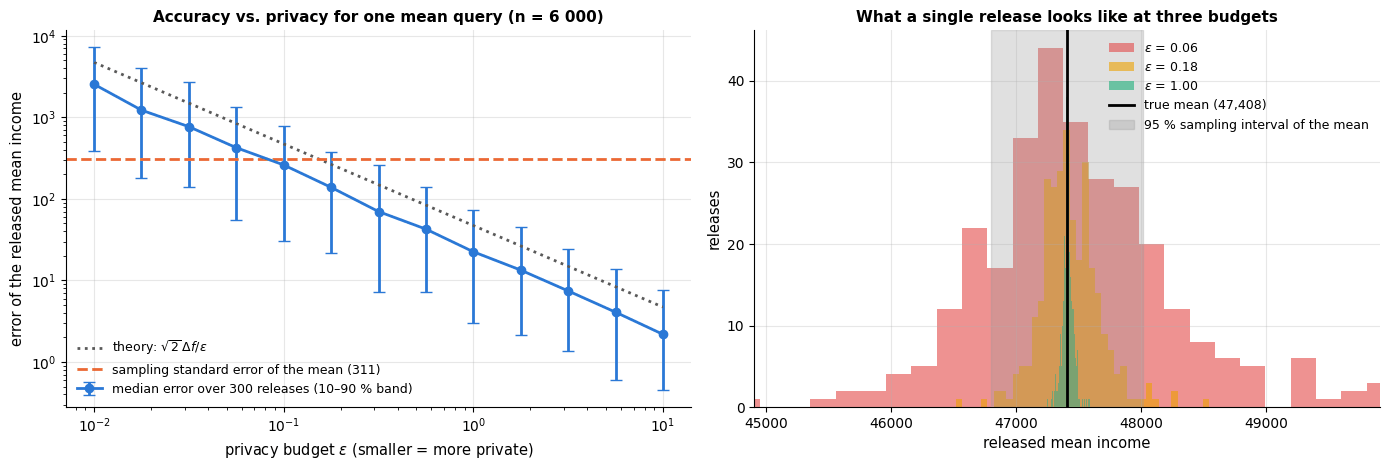

true mean income 47,408; one DP release with eps = 1: 47,366


In [29]:
def dp_mean(x, lo, hi, epsilon, rng):
    """epsilon-DP estimate of the mean of x (values clipped to [lo, hi]) via the Laplace mechanism."""
    x = np.clip(np.asarray(x, dtype=float), lo, hi)
    sensitivity = (hi - lo) / len(x)
    return x.mean() + rng.laplace(loc=0.0, scale=sensitivity / epsilon)

income = loans["income"].to_numpy()
LO, HI = 0.0, 200_000.0                      # the clipping range must NOT be chosen by looking at the data
true_mean = np.clip(income, LO, HI).mean()
sampling_se = income.std(ddof=1) / np.sqrt(len(income))

epsilons = np.logspace(-2, 1, 13)
draws = np.array([[dp_mean(income, LO, HI, eps, rng) for _ in range(300)] for eps in epsilons])
abs_err = np.abs(draws - true_mean)
median_err = np.median(abs_err, axis=1)
q10, q90 = np.percentile(abs_err, [10, 90], axis=1)
sensitivity = (HI - LO) / len(income)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].errorbar(epsilons, median_err, yerr=[median_err - q10, q90 - median_err], marker="o", capsize=4,
                 lw=2, color=PALETTE[0], label="median error over 300 releases (10–90 % band)")
axes[0].plot(epsilons, np.sqrt(2) * sensitivity / epsilons, ls=":", lw=2, color="0.35",
             label="theory: $\\sqrt{2}\\,\\Delta f / \\varepsilon$")
axes[0].axhline(sampling_se, color=PALETTE[1], ls="--", lw=2,
                label=f"sampling standard error of the mean ({sampling_se:.0f})")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("privacy budget $\\varepsilon$ (smaller = more private)")
axes[0].set_ylabel("error of the released mean income")
axes[0].set_title("Accuracy vs. privacy for one mean query (n = 6 000)", fontsize=11)
axes[0].legend(fontsize=9, loc="lower left")

for eps, color in zip([0.05, 0.2, 1.0], [PALETTE[7], PALETTE[3], PALETTE[2]]):
    d = draws[int(np.argmin(np.abs(epsilons - eps)))]
    axes[1].hist(d, bins=40, alpha=0.6, color=color, label=f"$\\varepsilon$ = {epsilons[int(np.argmin(np.abs(epsilons - eps)))]:.2f}")
axes[1].axvline(true_mean, color="black", lw=2, label=f"true mean ({true_mean:,.0f})")
axes[1].axvspan(true_mean - 1.96 * sampling_se, true_mean + 1.96 * sampling_se, color="0.6", alpha=0.3,
                label="95 % sampling interval of the mean")
axes[1].set_xlim(true_mean - 2500, true_mean + 2500)
axes[1].set_xlabel("released mean income")
axes[1].set_ylabel("releases")
axes[1].set_title("What a single release looks like at three budgets", fontsize=11)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f"true mean income {true_mean:,.0f}; one DP release with eps = 1: {dp_mean(income, LO, HI, 1.0, rng):,.0f}")

The error is proportional to $1/\varepsilon$ (a straight line of slope $-1$ on log–log
axes). From $\varepsilon \approx 0.1$ upwards the privacy noise is *smaller than the
statistical uncertainty of the mean itself* — a release with $\varepsilon = 1$ costs
essentially nothing in accuracy. Typical deployed values range from
$\varepsilon \approx 0.1$ to $\approx 10$ (the US 2020 Census used a total budget in the
tens); what is "enough" is a policy decision.

Differential privacy extends to model training: **DP-SGD** (Abadi et al., 2016) clips
each example's gradient and adds Gaussian noise before every update, so that the
trained parameters — and therefore every prediction — carry a formal privacy guarantee,
at a cost in accuracy that is largest for small datasets and rare classes. The recipe
applies to any model trained by gradient descent; the mature implementations live in the
deep-learning ecosystem (Opacus, TensorFlow Privacy), which a dedicated deep-learning
course covers. For the estimators of this course, the practical version of the same idea is
the trade-off curve of section 5.4: regularise until the leak is acceptable.

### 5.4 Membership inference

Why would a *model* leak? Because it fits its training data better than unseen data —
the generalisation gap of notebook 5 — and an attacker can measure that. A
**membership-inference attack** (Shokri et al., 2017) tries to decide whether a given
record was in the training set. The simplest version (Yeom et al., 2018) needs only the
model's confidence: compute the loss $\ell(\mathbf{x}, y) = -\log \hat{p}_y(\mathbf{x})$
and declare "member" if it is below a threshold. The attack's advantage is bounded by the
generalisation gap, which makes *overfitting a privacy problem*, not just an accuracy
problem. Let us attack two random forests trained on 300 hand-written digits: one with
fully grown trees, one regularised.

In [30]:
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier

X_digits, y_digits = load_digits(return_X_y=True)
X_digits = X_digits / 16.0                                             # pixel intensities in [0, 1]
X_in, X_rest, y_in, y_rest = train_test_split(X_digits, y_digits, train_size=300, stratify=y_digits, random_state=RANDOM_STATE)
X_out, _, y_out, _ = train_test_split(X_rest, y_rest, train_size=300, stratify=y_rest, random_state=RANDOM_STATE)

def per_sample_loss(model, X, y):
    proba = np.clip(model.predict_proba(X), 1e-12, 1.0)
    return -np.log(proba[np.arange(len(y)), y])

forests = {"overfit forest (min_samples_leaf=1)": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
           "regularised forest (min_samples_leaf=10)": RandomForestClassifier(n_estimators=200, min_samples_leaf=10, random_state=RANDOM_STATE)}
attack = {}
for name, forest in forests.items():
    forest.fit(X_in, y_in)
    loss_in, loss_out = per_sample_loss(forest, X_in, y_in), per_sample_loss(forest, X_out, y_out)
    is_member = np.r_[np.ones(len(loss_in)), np.zeros(len(loss_out))]
    attack_score = -np.r_[loss_in, loss_out]                          # low loss => "member"
    attack[name] = (loss_in, loss_out, roc_auc_score(is_member, attack_score))
    print(f"{name:42s} train acc {forest.score(X_in, y_in):.3f}  test acc {forest.score(X_out, y_out):.3f}  "
          f"mean loss in/out {loss_in.mean():.2f}/{loss_out.mean():.2f}  attack AUC {attack[name][2]:.3f}")

overfit forest (min_samples_leaf=1)        train acc 1.000  test acc 0.940  mean loss in/out 0.16/0.57  attack AUC 0.862
regularised forest (min_samples_leaf=10)   train acc 0.967  test acc 0.900  mean loss in/out 0.72/0.92  attack AUC 0.615


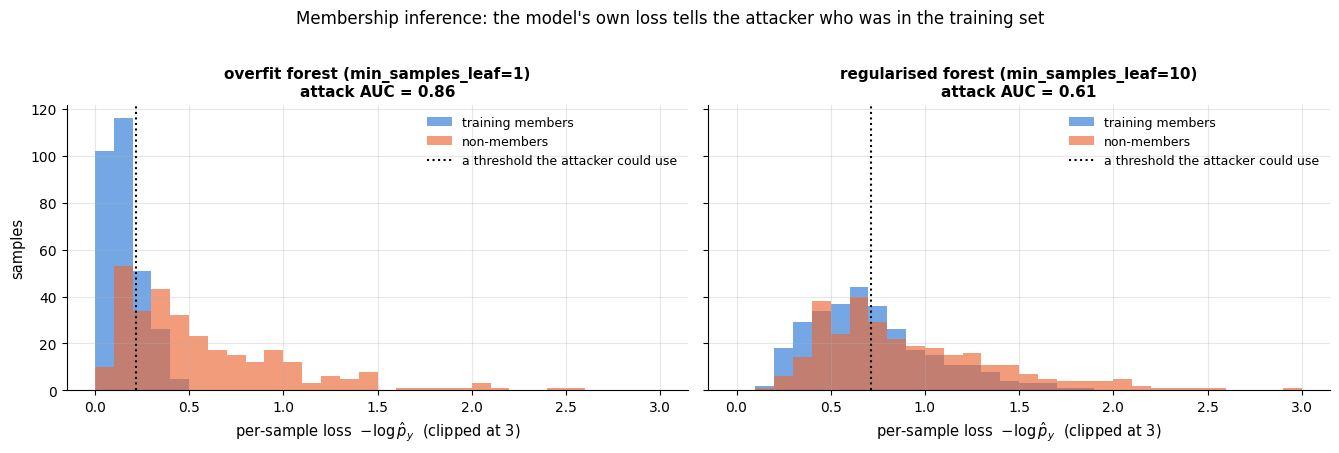

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4), sharey=True)
loss_bins = np.linspace(0, 3, 31)
for ax, (name, (loss_in, loss_out, auc)) in zip(axes, attack.items()):
    ax.hist(np.clip(loss_in, 0, 3), bins=loss_bins, alpha=0.65, color=PALETTE[0], label="training members")
    ax.hist(np.clip(loss_out, 0, 3), bins=loss_bins, alpha=0.65, color=PALETTE[1], label="non-members")
    ax.axvline(np.median(np.r_[loss_in, loss_out]), color="black", ls=":", lw=1.5,
               label="a threshold the attacker could use")
    ax.set_xlabel("per-sample loss  $-\\log \\hat p_y$  (clipped at 3)")
    ax.set_title(f"{name}\nattack AUC = {auc:.2f}", fontsize=11)
    ax.legend(fontsize=9)
axes[0].set_ylabel("samples")
fig.suptitle("Membership inference: the model's own loss tells the attacker who was in the training set", y=1.02)
plt.tight_layout()
plt.show()

The attack is only as strong as the memorisation it exploits, and that is a knob we
control. Sweeping `min_samples_leaf` traces the whole trade-off — how close to chance the
attack can be pushed, and what that costs in test accuracy.

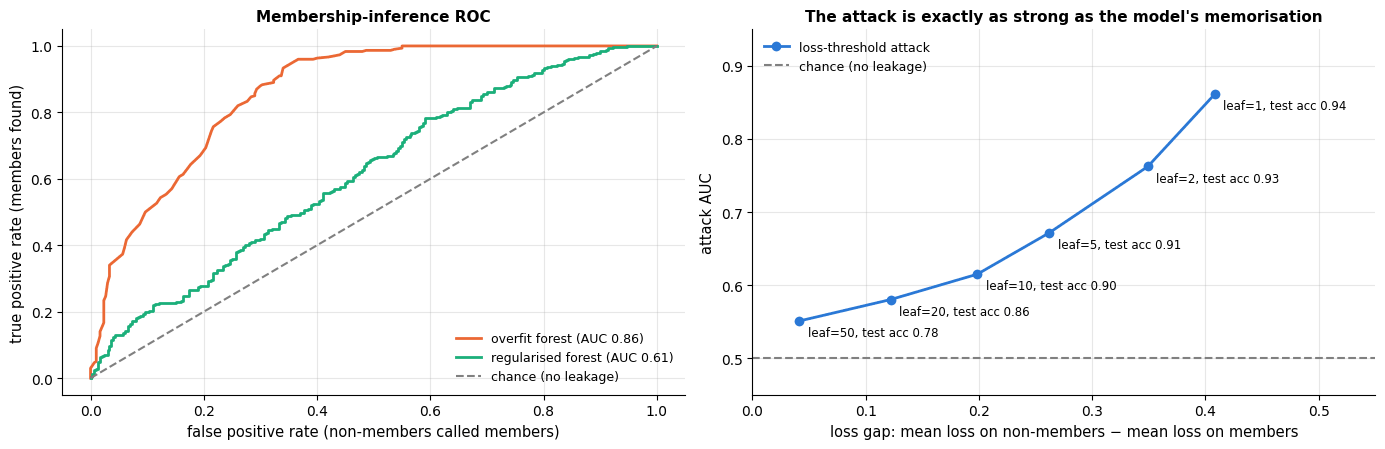

,min_samples_leaf,loss gap,train accuracy,test accuracy,attack AUC
0,1,0.408,1.000,0.940,0.862
1,2,0.349,1.000,0.927,0.762
2,5,0.262,0.997,0.913,0.672
3,10,0.199,0.967,0.900,0.615
4,20,0.122,0.923,0.857,0.580
5,50,0.041,0.833,0.783,0.551


In [32]:
leaf_grid = [1, 2, 5, 10, 20, 50]
sweep = []
for leaf in leaf_grid:
    forest = RandomForestClassifier(n_estimators=200, min_samples_leaf=leaf, random_state=RANDOM_STATE).fit(X_in, y_in)
    li, lo_ = per_sample_loss(forest, X_in, y_in), per_sample_loss(forest, X_out, y_out)
    member = np.r_[np.ones(len(li)), np.zeros(len(lo_))]
    sweep.append({"min_samples_leaf": leaf,
                  "loss gap": lo_.mean() - li.mean(),
                  "train accuracy": forest.score(X_in, y_in),
                  "test accuracy": forest.score(X_out, y_out),
                  "attack AUC": roc_auc_score(member, -np.r_[li, lo_])})
sweep = pd.DataFrame(sweep)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for (name, (loss_in, loss_out, auc)), color in zip(attack.items(), [PALETTE[1], PALETTE[2]]):
    member = np.r_[np.ones(len(loss_in)), np.zeros(len(loss_out))]
    fpr, tpr, _ = roc_curve(member, -np.r_[loss_in, loss_out])
    axes[0].plot(fpr, tpr, lw=2, color=color, label=f"{name.split(' (')[0]} (AUC {auc:.2f})")
axes[0].plot([0, 1], [0, 1], color="gray", ls="--", lw=1.5, label="chance (no leakage)")
axes[0].set_xlabel("false positive rate (non-members called members)")
axes[0].set_ylabel("true positive rate (members found)")
axes[0].set_title("Membership-inference ROC", fontsize=11)
axes[0].legend(fontsize=9, loc="lower right")

axes[1].plot(sweep["loss gap"], sweep["attack AUC"], marker="o", lw=2, color=PALETTE[0],
             label="loss-threshold attack")
for _, row in sweep.iterrows():
    axes[1].annotate(f"leaf={int(row['min_samples_leaf'])}, test acc {row['test accuracy']:.2f}",
                     xy=(row["loss gap"], row["attack AUC"]),
                     xytext=(6, -11), textcoords="offset points", fontsize=8.5)
axes[1].axhline(0.5, color="gray", ls="--", lw=1.5, label="chance (no leakage)")
axes[1].set_xlabel("loss gap: mean loss on non-members − mean loss on members")
axes[1].set_ylabel("attack AUC")
axes[1].set_xlim(0.0, 0.55)
axes[1].set_ylim(0.45, 0.95)
axes[1].set_title("The attack is exactly as strong as the model's memorisation", fontsize=11)
axes[1].legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()
display(sweep.round(3))

The overfit forest assigns its training points visibly lower losses than new points,
and the loss-threshold attack separates members from non-members with an AUC well above
0.8. Regularisation shrinks the loss gap and the attack's power with it, and the two move
together almost in lockstep — but the sweep also shows that privacy is *not* free here:
pushing the attack down towards chance with `min_samples_leaf = 50` costs a good deal of
test accuracy on only 300 training digits. Which point on that curve is acceptable is the
same kind of decision as the fairness trade-off of section 4.5. The defences are the
ones you already know — regularise, use more data, avoid memorising rare examples — plus
DP-SGD for a formal guarantee, and restricting the API (no confidence scores, rate
limits) as a practical one.

### 5.5 Federated learning

When data cannot leave the device or the hospital, **federated learning** (McMahan et
al., 2017) trains a shared model without centralising the data: each client computes an
update on its own data, a server averages the updates (*federated averaging*), and only
the model moves. This addresses data *collection* but not *inference* — model updates can
still leak training data, so federated systems combine averaging with differential
privacy and secure aggregation. It also brings new fairness questions (clients with more
data dominate the average) and new failure modes (malicious clients).

## 6. Robustness and safety

### 6.1 Adversarial examples

Szegedy et al. (2014) discovered that image classifiers can be fooled by perturbations
that are imperceptible to humans, and Goodfellow, Shlens & Szegedy (2015) explained why
with a linear argument: a perturbation $\boldsymbol{\eta}$ with $\|\boldsymbol{\eta}\|_\infty \le \varepsilon$
changes a linear score $\mathbf{w}^\top \mathbf{x}$ by up to
$\varepsilon \|\mathbf{w}\|_1$, which grows with the dimension — many tiny pushes in the
right direction add up. Their **fast gradient sign method** (FGSM) constructs the
perturbation in one step:

$$
\mathbf{x}_{\text{adv}} \;=\; \mathbf{x} + \varepsilon \cdot \operatorname{sign}\!\big(\nabla_{\mathbf{x}}\, \ell(\mathbf{x}, y)\big).
$$

For a multinomial logistic-regression classifier with weights $\mathbf{W} \in \mathbb{R}^{K \times d}$
and softmax probabilities $\mathbf{p}$, the gradient of the cross-entropy loss with respect
to the *input* has a closed form (the same computation as the backward pass of a neural network, one layer shorter):

$$
\nabla_{\mathbf{x}}\, \ell(\mathbf{x}, y) \;=\; \mathbf{W}^\top (\mathbf{p} - \mathbf{e}_y),
$$

where $\mathbf{e}_y$ is the one-hot vector of the true class. We attack a
logistic-regression digit classifier in NumPy and compare with *random* noise of the same
size.

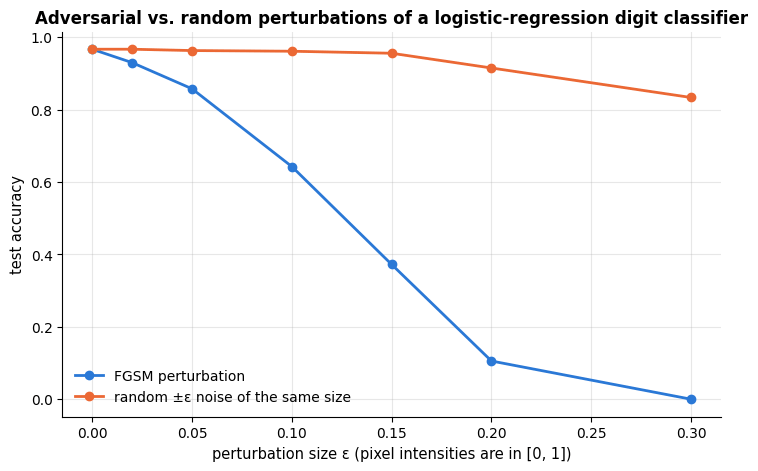

eps = 0.00   FGSM accuracy 0.967   random-noise accuracy 0.967
eps = 0.02   FGSM accuracy 0.930   random-noise accuracy 0.967
eps = 0.05   FGSM accuracy 0.857   random-noise accuracy 0.963
eps = 0.10   FGSM accuracy 0.643   random-noise accuracy 0.961
eps = 0.15   FGSM accuracy 0.372   random-noise accuracy 0.956
eps = 0.20   FGSM accuracy 0.106   random-noise accuracy 0.915
eps = 0.30   FGSM accuracy 0.000   random-noise accuracy 0.833


In [33]:
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(X_digits, y_digits, test_size=0.3, stratify=y_digits, random_state=RANDOM_STATE)
clf = LogisticRegression(max_iter=5000).fit(X_tr_d, y_tr_d)
W, b = clf.coef_, clf.intercept_                                       # (10, 64), (10,)

def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)

def input_gradient(X, y):
    """Gradient of the cross-entropy loss w.r.t. the inputs, one row per sample."""
    P = softmax(X @ W.T + b)
    P[np.arange(len(y)), y] -= 1.0                                     # p - e_y
    return P @ W

def fgsm(X, y, eps):
    return np.clip(X + eps * np.sign(input_gradient(X, y)), 0.0, 1.0)

eps_grid = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]
acc_adv = [clf.score(fgsm(X_te_d, y_te_d, e), y_te_d) for e in eps_grid]
acc_rand = [clf.score(np.clip(X_te_d + e * rng.choice([-1.0, 1.0], size=X_te_d.shape), 0, 1), y_te_d) for e in eps_grid]

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(eps_grid, acc_adv, marker="o", label="FGSM perturbation")
ax.plot(eps_grid, acc_rand, marker="o", label="random ±ε noise of the same size")
ax.set_xlabel("perturbation size ε (pixel intensities are in [0, 1])")
ax.set_ylabel("test accuracy")
ax.set_title("Adversarial vs. random perturbations of a logistic-regression digit classifier")
ax.legend()
plt.show()
for e, a, r in zip(eps_grid, acc_adv, acc_rand):
    print(f"eps = {e:.2f}   FGSM accuracy {a:.3f}   random-noise accuracy {r:.3f}")

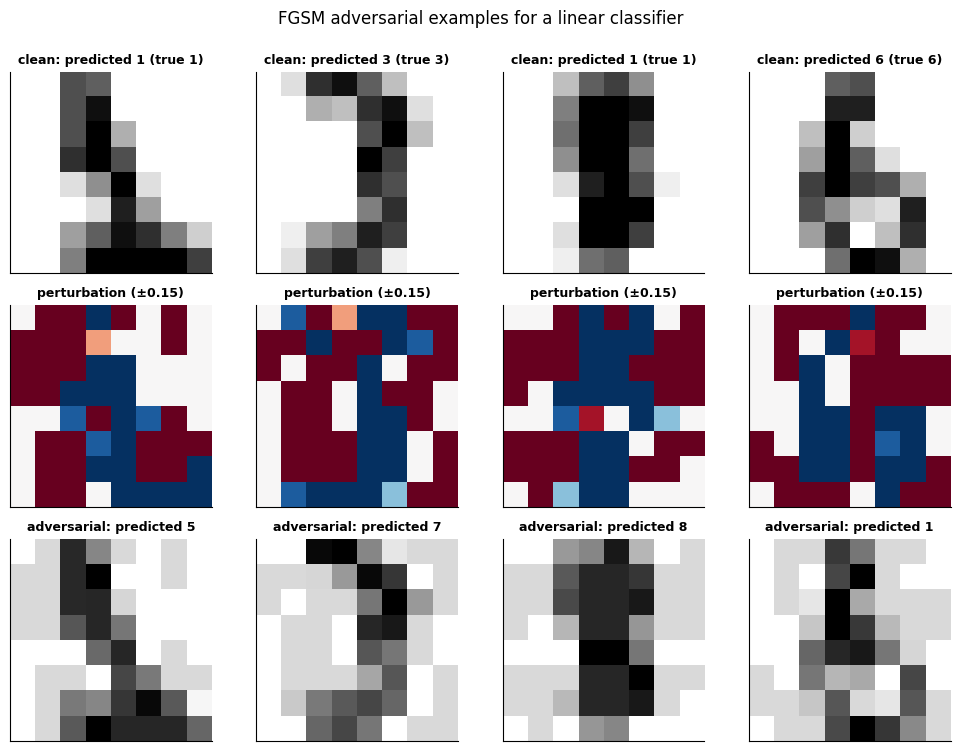

In [34]:
eps_show = 0.15
X_adv_all = fgsm(X_te_d, y_te_d, eps_show)
flipped = np.flatnonzero((clf.predict(X_te_d) == y_te_d) & (clf.predict(X_adv_all) != y_te_d))
idx = flipped[:4]                                # 4 of the 63 % that the attack flips at this eps
X_adv = X_adv_all[idx]
pred_clean, pred_adv = clf.predict(X_te_d[idx]), clf.predict(X_adv)
fig, axes = plt.subplots(3, 4, figsize=(10, 7.5))
for j, i in enumerate(idx):
    axes[0, j].imshow(X_te_d[i].reshape(8, 8), cmap="gray_r", vmin=0, vmax=1)
    axes[0, j].set_title(f"clean: predicted {pred_clean[j]} (true {y_te_d[i]})", fontsize=9)
    axes[1, j].imshow((X_adv[j] - X_te_d[i]).reshape(8, 8), cmap="RdBu_r", vmin=-eps_show, vmax=eps_show)
    axes[1, j].set_title(f"perturbation (±{eps_show})", fontsize=9)
    axes[2, j].imshow(X_adv[j].reshape(8, 8), cmap="gray_r", vmin=0, vmax=1)
    axes[2, j].set_title(f"adversarial: predicted {pred_adv[j]}", fontsize=9)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.suptitle("FGSM adversarial examples for a linear classifier", y=0.995)
plt.tight_layout()
plt.show()

A perturbation of 0.15 on a 0–1 scale — a light grey haze that leaves every digit
perfectly legible — cuts the accuracy from 97 % to below 40 %, and at 0.2 the classifier
is at chance level (0.10 for ten classes), while random noise of the same magnitude is
nearly harmless. (The four digits above are drawn from the majority that the attack does
flip at $\varepsilon = 0.15$; about a third of the test set survives it.) Deep
networks are at least as vulnerable, and the perturbations transfer between models.
Defences (adversarial training, certified robustness, input preprocessing) are an active
research area; for deployed systems the practical questions are *who* could manipulate
the inputs, *what* they gain, and whether the system falls back to a human when inputs
look unusual.

### 6.2 Distribution shift, uncertainty and abstention

Adversaries are a worst case of a general problem: the deployment distribution differs
from the training distribution (notebook 18 covers drift detection). A model cannot be
right about inputs unlike anything it has seen — but it can *know* that it does not know.
**Selective classification** (Geifman & El-Yaniv, 2017) lets the model abstain when its
confidence is low and hand the case to a human; the trade-off is between *coverage* (the
fraction of cases decided automatically) and accuracy on the covered cases. The maximum
predicted probability is a crude but surprisingly useful confidence signal.

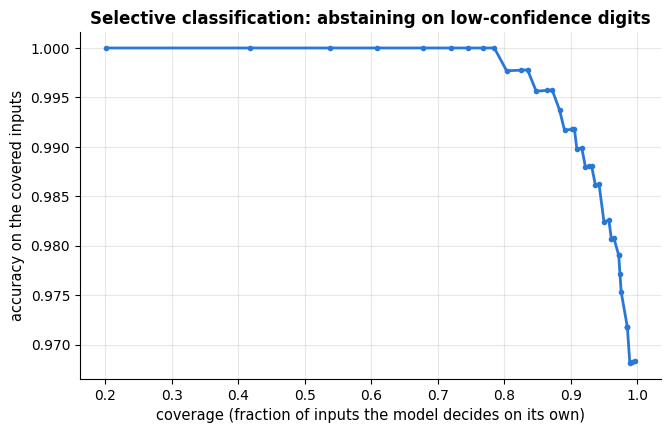

confidence >= 0.50: coverage 0.959, accuracy on covered 0.983
confidence >= 0.80: coverage 0.831, accuracy on covered 0.998
confidence >= 0.95: coverage 0.556, accuracy on covered 1.000


In [35]:
proba = clf.predict_proba(X_te_d)
confidence, prediction = proba.max(axis=1), proba.argmax(axis=1)
thresholds = np.linspace(0.3, 0.99, 40)
coverage = [np.mean(confidence >= t) for t in thresholds]
selective_acc = [np.mean(prediction[confidence >= t] == y_te_d[confidence >= t]) for t in thresholds]

fig, ax = plt.subplots()
ax.plot(coverage, selective_acc, marker=".", lw=2)
ax.set_xlabel("coverage (fraction of inputs the model decides on its own)")
ax.set_ylabel("accuracy on the covered inputs")
ax.set_title("Selective classification: abstaining on low-confidence digits")
plt.show()
for t in [0.5, 0.8, 0.95]:
    m = confidence >= t
    print(f"confidence >= {t:.2f}: coverage {m.mean():.3f}, accuracy on covered {np.mean(prediction[m] == y_te_d[m]):.3f}")

Uncertainty estimates are only as good as the model's calibration (notebook 7) and
degrade under shift — a confidently wrong model is the dangerous case. That is why
*human oversight* is a design requirement, not a fallback: someone must be able to see,
question and override the decision, and the interface must make that realistic rather
than a rubber stamp.

### 6.3 Regulation, documentation and the cost of computation

**The EU AI Act** (Regulation (EU) 2024/1689) classifies AI systems by risk:

| Tier | Examples | Obligations |
|---|---|---|
| **Unacceptable** (prohibited) | social scoring by public authorities, manipulative systems, some biometric categorisation | banned |
| **High risk** | biometrics, critical infrastructure, education, employment, essential services incl. *creditworthiness assessment*, law enforcement, migration, justice | risk management, data governance, technical documentation, logging, transparency, human oversight, accuracy/robustness/security requirements, conformity assessment |
| **Limited risk** | chatbots, deep fakes | transparency (tell people they interact with AI / synthetic content) |
| **Minimal risk** | spam filters, game AI | none beyond existing law |

A loan-approval model like the one in this notebook is a high-risk system: every analysis
we did — bias sources, group metrics, calibration, robustness, documentation — maps onto
an obligation. Outside the law, dozens of AI-ethics guidelines from companies,
governments and professional bodies converge on the same handful of principles —
transparency, justice and fairness, non-maleficence, responsibility, privacy — while
differing on what they mean in practice (Jobin, Ienca & Vayena, 2019).

**Documentation** turns good intentions into artefacts that can be checked. **Model
cards** (Mitchell et al., 2019) report intended use, evaluation *disaggregated by group*,
and known limitations; **datasheets for datasets** (Gebru et al., 2021) record how the
data were collected, by whom, with what consent, and what they should not be used for
(exercise 5 asks you to write one for the loan data). Notebook 18 has templates for both.
Lightweight **checklists** such as *deon* (a data-science ethics checklist maintained by
DrivenData) prompt the questions at each stage; **impact assessments** (algorithmic or
data-protection) are their formal counterpart.

**Environmental cost.** Strubell, Ganesh & McCallum (2019) estimated that training one
large NLP model with neural architecture search emitted on the order of 280 t of
CO₂-equivalent — several times the lifetime emissions of a car — and Bender et al. (2021)
argue that the risks of ever-larger language models (environmental, financial, and the
encoding of hegemonic views from uncurated web text) fall on people who do not share
their benefits. For most practitioners the actionable version is modest: measure what a
training run costs, prefer smaller models when they are good enough (notebook 10's
tabular results are a reminder that they often are), and report compute alongside
accuracy.

## 7. A responsible-ML workflow

The questions below are worth asking — and writing the answers down — at each stage of
every project.

| Stage | Questions |
|---|---|
| **Problem framing** | Who is affected, and are they at the table? What is the decision, what are the costs of each error, and for whom? Is a model the right tool (Selbst's solutionism trap)? Which fairness criterion fits the decision (section 4.6)? What law applies (GDPR, AI Act tier)? |
| **Data** | What is the lawful basis? Is the label the outcome or a past decision? How was the sample drawn, and who is missing? Which features are proxies for protected attributes? Is there a datasheet? |
| **Modelling** | Are groups represented in training and validation? Is performance disaggregated by group, and calibrated within each? Have you audited proxies? Is the model no more complex than the problem needs? |
| **Evaluation** | Which fairness metrics, at the *deployed* threshold? Error analysis by segment? Robustness to shift and manipulation? Uncertainty and abstention? |
| **Deployment** | Is there a human in the loop with real authority? Are decisions logged and explainable to the person affected? Is there a monitoring plan for drift *and* for fairness metrics over time? A model card? A way to contest a decision? |
| **Retirement** | When and how will the model be re-validated or withdrawn? What happens to the data? |

### 7.1 Applying it to the loan case

**Findings.** (1) The historical approval label encodes a direct penalty against group B:
approvals were 23 points lower than group A's while repayment was only 5 points lower.
(2) A model trained to imitate those decisions reproduces the penalty in full — denying
qualified group-B applicants about three times as often — and deleting the `group`
column does nothing because the postcode is a perfect proxy. (3) A model trained on the
*outcome*, without group or postcode, is calibrated within both groups, more profitable
than the historical process, and far fairer; a residual gap (about 0.08 in true positive
rate) remains because group B's incomes are lower. (4) Group-specific thresholds can
close that gap at a small cost in profit, but require using the group at decision time.

**Recommendation.** Do not deploy any model trained on the historical `approved` label.
Train on repayment outcomes; exclude the postcode and other proxies from the features;
report selection rate, TPR, FPR and calibration by group on every evaluation and in the
model card; decide with the credit and compliance teams whether the residual
opportunity gap is to be closed by post-processing (check its legality in the relevant
jurisdiction) or by adjusting the product (for example smaller loans at the margin); keep
a human review path for denied applications and log the reasons given; monitor the group
metrics monthly, because the outcome label itself is only observed for *approved* loans —
a selection effect that will drift the training data over time (exercise 6 explores it).

## Summary

- ML systems cause **allocation, quality-of-service, representation, privacy and safety
  harms**; bias enters through the **history** behind the data, the **sample**, the
  **measurement** of features and labels, **aggregation**, **evaluation** and
  **deployment** — and a biased *label* cannot be fixed downstream.
- Group fairness metrics are all functions of the **per-group confusion matrix**:
  demographic parity and disparate impact (independence), equal opportunity and
  equalised odds (separation), predictive parity and calibration by group (sufficiency).
  With unequal base rates, **separation and sufficiency cannot both hold** — choose, and
  justify the choice.
- **Unawareness does not work** (proxies). Reweighing (pre-), constraints (in-) and
  group-specific thresholds (post-processing) do, each with side effects; the honest
  summary of the options is the **accuracy–fairness Pareto front**.
- **Anonymisation is fragile**; **differential privacy** bounds what any output reveals
  about any individual, with noise proportional to sensitivity/$\varepsilon$ and a budget
  that composes; **overfitting is a privacy leak** (membership inference).
- Models are fragile to **adversarial perturbations** and to **distribution shift**;
  calibrated uncertainty, abstention, human oversight and monitoring are the engineering
  answers, and documentation (model cards, datasheets) plus regulation (GDPR, AI Act)
  the institutional ones.

| Question | Tool in this notebook |
|---|---|
| Is the label the outcome or a decision? | compare `approved` vs `repaid` by group (section 2) |
| Are decisions equal across groups? | `group_rates`, `fairness_summary` — selection rate, DI ratio, TPR/FPR/PPV gaps |
| Do the scores mean the same thing for everyone? | `calibration_curve` per group |
| Is the attribute hidden in the features? | proxy audit: predict the group from the features |
| Reduce the gap | reweighing (`sample_weight`), `equal_opportunity_thresholds`, Pareto front over thresholds; `fairlearn` |
| Release a statistic safely | `dp_mean` (Laplace mechanism), sensitivity, budget |
| Does the model leak its training data? | loss-threshold membership inference |
| Can inputs be manipulated? | `fgsm`, accuracy vs. $\varepsilon$; selective classification |

**Next steps:** notebook 20 (capstone) runs the group-fairness check on the churn model;
notebook 17 supplies the explanations that Article 22 and the AI Act's transparency
duties call for; notebook 18 has the model-card and monitoring templates.

## Exercises

### Exercise 1 — A second model (easy)
Train a `HistGradientBoostingClassifier` on the `approved` label with all features and
compute the full fairness summary at $\tau = 0.8$. Does a more flexible model make the
disparity better or worse? Then repeat on the `repaid` label without proxies.

<details><summary>Solution sketch</summary>

Wrap the classifier in the same `ColumnTransformer` (one-hot encoding for the
categoricals) and reuse `group_rates`/`fairness_summary`. A flexible model imitates the
biased decisions at least as faithfully as logistic regression, so the gaps are similar or
larger; on the outcome label without proxies it lands close to the logistic outcome model.
</details>

### Exercise 2 — Reweighing for the outcome model (easy)
Apply `reweighing_weights` with the `repaid` label and the outcome model's features.
Which weights result, and why are they close to 1? What does this say about when
reweighing is useful?

<details><summary>Solution sketch</summary>

The joint distribution of group and `repaid` is close to independent (repayment rates
0.86 vs 0.80), so the weights are within ±10 % of 1 and change little. Reweighing targets
independence between label and group; when the label is only mildly dependent on the
group, it has little to correct — and it cannot remove a disparity that enters through
the features rather than the label.
</details>

### Exercise 3 — Equalised odds by randomisation (medium)
Implement the Hardt et al. (2016) construction for *equalised odds*: for each group, pick
two thresholds and a mixing probability so that both groups reach the same (FPR, TPR)
point, chosen to maximise profit among the points in the intersection of the two ROC
convex hulls. Compare its profit with the equal-opportunity solution.

<details><summary>Solution sketch</summary>

For group $g$, a decision "approve with probability $q$ if $R \ge \tau_1$, and with
probability $q'$ if $\tau_2 \le R < \tau_1$" reaches any point on the segment between the
ROC points of $\tau_1$ and $\tau_2$. Build each group's ROC convex hull
(`scipy.spatial.ConvexHull` or a monotone chain), sample target points inside the
intersection, and for each target solve for the mixing weights by linear interpolation
between adjacent hull vertices. Profit is lower than for equal opportunity alone (an extra
constraint), and the randomisation itself is hard to defend to an applicant — a known
objection to the method.
</details>

### Exercise 4 — Privacy budget (medium)
Release the mean income of each `purpose` category with $\varepsilon = 0.5$ per query. What
total budget have you spent? Repeat the whole release 200 times and plot the error of the
*smallest* category against that of the largest. Then release the same overall mean 50
times with $\varepsilon = 0.1$ each and average the results: how does the error of the
average compare with a single release at $\varepsilon = 5$?

<details><summary>Solution sketch</summary>

Five disjoint categories: by *parallel composition* the total is still $0.5$ (each record
is in one category), but the small categories get much larger relative errors because the
sensitivity $(\text{hi}-\text{lo})/n_g$ is larger. Fifty releases at $\varepsilon = 0.1$
cost $\varepsilon = 5$ by sequential composition, and averaging fifty Laplace draws of
scale $10\,\Delta$ gives an error of about $10\Delta\sqrt{2/50} \approx 2\Delta$, versus
$\sqrt{2}\,\Delta/5 \approx 0.28\Delta$ for a single release at $\varepsilon = 5$: repeated
queries are a bad deal — spend the budget once.
</details>

### Exercise 5 — A datasheet for `loan_applications.csv` (medium)
Following Gebru et al. (2021), write a datasheet for the loan data: motivation,
composition, collection process, preprocessing, uses, distribution, maintenance. Use
`data/make_datasets.py` as the "collection process" and be explicit about what the
dataset must *not* be used for.

<details><summary>Solution sketch</summary>

Key entries: *purpose* — teaching fairness auditing; *composition* — 6 000 synthetic
applicants, 65/35 groups, two labels with a documented relation; *collection* — generated
from a logistic model with a known group penalty, seed 2024; *known biases* — label bias
on `approved`, income gap by group, `zip_prefix` is a perfect proxy; *prohibited uses* —
any real credit decision, any claim about real populations; *maintenance* — regenerated
by the script, versioned with the course.
</details>

### Exercise 6 — Selective labels (hard)
In real lending, `repaid` is observed only for applicants who were *approved*. Simulate
this: keep `repaid` only where `approved == 1`, train the outcome model on that subset,
and evaluate it on the full test set. How do the group metrics change, and why? Suggest
two remedies.

<details><summary>Solution sketch</summary>

The training set now under-represents group B (fewer approvals) and, within group B,
over-represents the strongest applicants; the model's calibration for group B degrades
and the TPR gap widens. Remedies: treat it as a missing-data problem (inverse
probability weighting by the historical approval propensity, notebook 4's MAR framework),
or run a small randomised *exploration* policy that approves a fraction of marginal
applicants to collect unbiased outcomes.
</details>

## References and further reading

### Textbooks

- Barocas, S., Hardt, M., & Narayanan, A. (2023). *Fairness and Machine Learning: Limitations and Opportunities*. MIT Press. (free at https://fairmlbook.org) — The reference for this notebook; chapter 3 covers the three criteria and the impossibility results, chapter 5 the legal background.
- Dwork, C., & Roth, A. (2014). The algorithmic foundations of differential privacy. *Foundations and Trends in Theoretical Computer Science*, 9(3–4), 211–407. (free) — The textbook on differential privacy; chapters 2–3 cover the definition, the Laplace mechanism and composition.
- O'Neil, C. (2016). *Weapons of Math Destruction*. Crown. — Case studies of harmful models in credit, employment, policing and education, for a general audience.

### Papers

- Angwin, J., Larson, J., Mattu, S., & Kirchner, L. (2016). Machine bias. *ProPublica*, May 23, 2016. — The COMPAS investigation.
- Chouldechova, A. (2017). Fair prediction with disparate impact: a study of bias in recidivism prediction instruments. *Big Data*, 5(2), 153–163. — The identity of section 3.4 and its consequences.
- Kleinberg, J., Mullainathan, S., & Raghavan, M. (2017). Inherent trade-offs in the fair determination of risk scores. *Proceedings of ITCS 2017*. — The score-level impossibility theorem.
- Buolamwini, J., & Gebru, T. (2018). Gender Shades: intersectional accuracy disparities in commercial gender classification. *Proceedings of FAT\* 2018*, PMLR 81, 77–91.
- Obermeyer, Z., Powers, B., Vogeli, C., & Mullainathan, S. (2019). Dissecting racial bias in an algorithm used to manage the health of populations. *Science*, 366(6464), 447–453. — The clearest published example of label (measurement) bias.
- Selbst, A. D., boyd, d., Friedler, S. A., Venkatasubramanian, S., & Vertesi, J. (2019). Fairness and abstraction in sociotechnical systems. *Proceedings of FAT\* 2019*, 59–68. — The five traps of section 1.3.
- Suresh, H., & Guttag, J. (2021). A framework for understanding sources of harm throughout the machine learning life cycle. *Proceedings of EAAMO 2021*. — The taxonomy of bias sources in section 2.
- Mehrabi, N., Morstatter, F., Saxena, N., Lerman, K., & Galstyan, A. (2021). A survey on bias and fairness in machine learning. *ACM Computing Surveys*, 54(6), 1–35. — A broad survey of definitions and methods.
- Dwork, C., Hardt, M., Pitassi, T., Reingold, O., & Zemel, R. (2012). Fairness through awareness. *Proceedings of ITCS 2012*, 214–226. — Individual fairness, and why unawareness fails.
- Hardt, M., Price, E., & Srebro, N. (2016). Equality of opportunity in supervised learning. *Advances in NIPS 29*. — Equal opportunity, equalised odds and the threshold post-processing of section 4.4.
- Kusner, M. J., Loftus, J., Russell, C., & Silva, R. (2017). Counterfactual fairness. *Advances in NeurIPS 30*.
- Feldman, M., Friedler, S. A., Moeller, J., Scheidegger, C., & Venkatasubramanian, S. (2015). Certifying and removing disparate impact. *Proceedings of KDD 2015*, 259–268. — Disparate impact, the four-fifths rule and a repair method.
- Kamiran, F., & Calders, T. (2012). Data preprocessing techniques for classification without discrimination. *Knowledge and Information Systems*, 33(1), 1–33. — Reweighing (section 4.2) and related pre-processing methods.
- Agarwal, A., Beygelzimer, A., Dudík, M., Langford, J., & Wallach, H. (2018). A reductions approach to fair classification. *Proceedings of ICML 2018*. — The in-processing method behind `fairlearn`'s `ExponentiatedGradient`.
- Corbett-Davies, S., & Goel, S. (2018). The measure and mismeasure of fairness: a critical review of fair machine learning. *arXiv:1808.00023*. — A critical view of the group-fairness definitions.
- Sweeney, L. (2002). k-anonymity: a model for protecting privacy. *International Journal of Uncertainty, Fuzziness and Knowledge-Based Systems*, 10(5), 557–570.
- Dwork, C., McSherry, F., Nissim, K., & Smith, A. (2006). Calibrating noise to sensitivity in private data analysis. *Proceedings of TCC 2006*, 265–284. — The original differential-privacy paper and the Laplace mechanism.
- Abadi, M., Chu, A., Goodfellow, I., McMahan, H. B., Mironov, I., Talwar, K., & Zhang, L. (2016). Deep learning with differential privacy. *Proceedings of ACM CCS 2016*, 308–318. — DP-SGD.
- Shokri, R., Stronati, M., Song, C., & Shmatikov, V. (2017). Membership inference attacks against machine learning models. *Proceedings of IEEE S&P 2017*, 3–18.
- Yeom, S., Giacomelli, I., Fredrikson, M., & Jha, S. (2018). Privacy risk in machine learning: analyzing the connection to overfitting. *Proceedings of IEEE CSF 2018*. — The loss-threshold attack of section 5.4 and its link to the generalisation gap.
- McMahan, H. B., Moore, E., Ramage, D., Hampson, S., & Agüera y Arcas, B. (2017). Communication-efficient learning of deep networks from decentralized data. *Proceedings of AISTATS 2017*. — Federated averaging.
- Szegedy, C., et al. (2014). Intriguing properties of neural networks. *ICLR 2014*; and Goodfellow, I. J., Shlens, J., & Szegedy, C. (2015). Explaining and harnessing adversarial examples. *ICLR 2015*. — Adversarial examples and FGSM.
- Geifman, Y., & El-Yaniv, R. (2017). Selective classification for deep neural networks. *Advances in NeurIPS 30*. — Abstention with a coverage–accuracy trade-off (section 6.2).
- Mitchell, M., et al. (2019). Model cards for model reporting. *Proceedings of FAT\* 2019*, 220–229; and Gebru, T., et al. (2021). Datasheets for datasets. *Communications of the ACM*, 64(12), 86–92.
- Wachter, S., Mittelstadt, B., & Floridi, L. (2017). Why a right to explanation of automated decision-making does not exist in the General Data Protection Regulation. *International Data Privacy Law*, 7(2), 76–99.
- Strubell, E., Ganesh, A., & McCallum, A. (2019). Energy and policy considerations for deep learning in NLP. *Proceedings of ACL 2019*; and Bender, E. M., Gebru, T., McMillan-Major, A., & Shmitchell, S. (2021). On the dangers of stochastic parrots: can language models be too big? *Proceedings of FAccT 2021*, 610–623.
- Jobin, A., Ienca, M., & Vayena, E. (2019). The global landscape of AI ethics guidelines. *Nature Machine Intelligence*, 1, 389–399. — What 84 sets of AI-ethics guidelines agree (and disagree) on.

### Documentation and online resources

- Regulation (EU) 2016/679 (General Data Protection Regulation) and Regulation (EU) 2024/1689 (the AI Act). *Official Journal of the European Union*. — Primary sources for sections 5.1 and 6.3.
- Equal Employment Opportunity Commission et al. (1978). *Uniform Guidelines on Employee Selection Procedures*, 29 C.F.R. Part 1607 (§ 1607.4 D). — The origin of the four-fifths rule used in section 3.2.
- Bird, S., et al. (2020). Fairlearn: a toolkit for assessing and improving fairness in AI. Microsoft Technical Report MSR-TR-2020-32; documentation at https://fairlearn.org — Metrics, mitigation algorithms and a good user guide on choosing fairness criteria.
- deon — an ethics checklist for data scientists (DrivenData) — https://deon.drivendata.org/ (free)
- scikit-learn user guide, *Probability calibration* — https://scikit-learn.org/stable/modules/calibration.html — for the per-group reliability diagrams.